> ### ⚠️ Phiên bản đã sửa — thay đổi so với bản gốc
>
> **Vấn đề của bản gốc:** tập đặc trưng có `LAG_1` và `LAG_2` (giá trị 30 và 60 phút trước). Nhu cầu điện quốc gia gần như không đổi trong 30 phút, nên mô hình gần như "đọc lại" chính giá trị cần dự báo → $R^2 = 0{,}9972$ **cao ảo**. Đây **không phải rò rỉ dữ liệu (data leakage)** — split thời gian, rolling `shift`, và MI screening đều đúng — mà là **lệch tầm dự báo (forecast horizon mismatch)**: các mô hình học máy chỉ dự báo trước 30 phút, trong khi hai đường cơ sở SNaive phải dự báo trước 1 ngày và 1 tuần. So sánh "ML giảm RMSE 87%" vì thế là khập khiễng.
>
> **Đã sửa:**
> 1. Notebook 03: bỏ `LAG_1`, `LAG_2` → $L = \{12, 24, 36, 48, 336\}$ (lead time tối thiểu 6 giờ).
> 2. Notebook 03: rolling `shift(1)` → `shift(12)`, nếu không thì rolling vẫn rò rỉ info cận thời gian.
> 3. Notebook 04 (file này): nạp `uk_electricity_features_lag12.csv`, thêm baseline `SNaive Lag12` để so sánh **cùng lead time 6 giờ** với các mô hình học máy.
>
> **Kết quả mới trên test 2025:** LightGBM vô địch (MAPE 3,61%, $R^2$ 0,9591), XGBoost thứ hai (MAPE 3,81%, $R^2$ 0,9559). RMSE giảm **49,7%** so với SNaive Daily (thay vì 87% ảo). **Lưu ý: mô hình vô địch đổi từ XGBoost sang LightGBM** — cần cập nhật lại các câu khẳng định "XGBoost is the champion model" trong paper.

# Notebook: `04_model_training_and_evaluation.ipynb`

### Objective & Scope

Notebook này thực thi giai đoạn kiểm chứng thực nghiệm cốt lõi của đề xuất nghiên cứu. Sử dụng ma trận đặc trưng đa chiều sạch `uk_electricity_features.csv` được bàn giao từ `03_feature_engineering_and_selection.ipynb`, ta huấn luyện, tinh chỉnh và đối chiếu một cách hệ thống sáu kiến trúc mô hình khác nhau hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$), cùng với Linear Regression, Random Forest, XGBoost và LightGBM để dự báo **Nhu cầu điện năng quốc gia (National Demand, ND)** của lưới điện Vương quốc Anh



###Thiết lập môi trường

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 5),
})

###Hàm hỗ trợ (Helper Functions)

Ba hàm hỗ trợ dưới đây được kế thừa trực tiếp từ mục "0.1 Helper Function" của `Hourly_Energy_Consumption.ipynb`, có điều chỉnh cho phù hợp với một chuỗi thời gian quốc gia duy nhất:

* `ml_error()`: tính bốn chỉ số R2, MAE, RMSE và MAPE cho một tập dự báo.
* `mean_percentage_error()`: tính sai số phần trăm có dấu (MPE), dùng để chẩn đoán thiên lệch hệ thống (overestimate hay underestimate) của mô hình cuối cùng ở phần 8.2.
* `cross_validation()`: thay vì vòng lặp qua nhiều công ty điện lực như notebook tham chiếu, hàm này thực hiện Cross Validation dạng cửa sổ mở rộng theo thời gian (expanding window) trên một chuỗi thời gian liên tục duy nhất, chia `X_training` thành `kfold` cặp huấn luyện/kiểm định liên tiếp lùi dần về quá khứ, mỗi cặp cách nhau `validation_days` ngày.

In [2]:
def mean_percentage_error(y, yhat):
    return np.mean((y - yhat) / y)

def mean_absolute_percentage_error(y, yhat):
    return np.mean(np.abs((y - yhat) / y)) * 100

def ml_error(model_name, y, yhat):
    r2 = r2_score(y, yhat)
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mape = mean_absolute_percentage_error(y, yhat)
    return pd.DataFrame({"Model Name": model_name, "R2": r2, "MAE": mae,
                          "RMSE": rmse, "MAPE (%)": mape}, index=[0])

def cross_validation(X_training, kfold, model_name, model, feature_cols, target_col="ND",
                       validation_days=120, verbose=False):
    r2_list, mae_list, rmse_list, mape_list = [], [], [], []
    for k in reversed(range(1, kfold + 1)):
        if verbose:
            print(f"\nKFold Number: {k}")
        validation_start = X_training.index.max() - pd.Timedelta(days=k * validation_days)
        validation_end = X_training.index.max() - pd.Timedelta(days=(k - 1) * validation_days)

        training_fold = X_training[X_training.index < validation_start]
        validation_fold = X_training[(X_training.index >= validation_start) & (X_training.index <= validation_end)]

        xtraining_fold, ytraining_fold = training_fold[feature_cols], training_fold[target_col]
        xvalidation_fold, yvalidation_fold = validation_fold[feature_cols], validation_fold[target_col]

        if verbose:
            print(f"  Train: {xtraining_fold.shape[0]:,} dòng | Validation: {xvalidation_fold.shape[0]:,} dòng")

        m = model.fit(xtraining_fold, ytraining_fold)
        yhat_fold = m.predict(xvalidation_fold)
        m_result = ml_error(model_name, yvalidation_fold, yhat_fold)

        r2_list.append(m_result["R2"][0])
        mae_list.append(m_result["MAE"][0])
        rmse_list.append(m_result["RMSE"][0])
        mape_list.append(m_result["MAPE (%)"][0])

    return pd.DataFrame({
        "Model Name": model_name,
        "R2 CV": f"{np.mean(r2_list):.4f} +/- {np.std(r2_list):.4f}",
        "MAE CV": f"{np.mean(mae_list):.2f} +/- {np.std(mae_list):.2f}",
        "RMSE CV": f"{np.mean(rmse_list):.2f} +/- {np.std(rmse_list):.2f}",
        "MAPE CV (%)": f"{np.mean(mape_list):.2f} +/- {np.std(mape_list):.2f}",
    }, index=[0])

results = []
results_cv = []
predictions = {}

### Feature Matrix Ingestion

Ta nạp ma trận đặc trưng dày đặc chứa các đặc trưng trễ tự hồi quy ($H \in \{1,2,12,24,36,48,336\}$), các thống kê trượt, và các biến lượng giác tuần hoàn đã được xây dựng và kiểm định ở notebook 03.

In [3]:
df = pd.read_csv("uk_electricity_features_lag12.csv")   # SỬA: feature matrix mới (lag>=12)
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df = df.set_index("DATETIME").sort_index()

so_nan = df.isna().sum().sum()
print(f"Kích thước ma trận đặc trưng: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Giai đoạn: {df.index.min()} đến {df.index.max()}")
print(f"Tổng số giá trị NaN: {so_nan:,}")

if so_nan > 0:
    df = df.dropna()
    print(f"Đã loại bỏ NaN, làm sạch một lần duy nhất ngay tại bước nạp dữ liệu. Kích thước sau khi làm sạch: {df.shape[0]:,} dòng.")
else:
    print("Không có NaN — ma trận đặc trưng đã được bàn giao sạch từ notebook 03, không cần dropna() ở bất kỳ bước huấn luyện mô hình nào phía sau.")

df.head()

Kích thước ma trận đặc trưng: 104,880 dòng x 46 cột
Giai đoạn: 2020-01-08 00:00:00 đến 2025-12-31 23:30:00
Tổng số giá trị NaN: 0
Không có NaN — ma trận đặc trưng đã được bàn giao sạch từ notebook 03, không cần dropna() ở bất kỳ bước huấn luyện mô hình nào phía sau.


,ND,TSD,ENGLAND_WALES_DEMAND,ND_LAG_48,ENGLAND_WALES_DEMAND_LAG_48,ENGLAND_WALES_DEMAND_LAG_336,ND_LAG_336,TSD_LAG_48,TSD_LAG_336,SETTLEMENT_PERIOD,ND_ROLL_MEAN_48,ND_ROLL_STD_24,EMBEDDED_SOLAR_CAPACITY,ND_ROLL_STD_48,PUMP_STORAGE_PUMPING,ENGLAND_WALES_DEMAND_LAG_12,ND_ROLL_MEAN_8,ND_LAG_12,PERIOD_SIN,TSD_LAG_12,ND_ROLL_MEAN_24,SOLAR_ROLL_MEAN_48,SOLAR_ROLL_MEAN_24,ENGLAND_WALES_DEMAND_LAG_36,ND_LAG_36,EMBEDDED_SOLAR_GENERATION,TSD_LAG_36,PERIOD_COS,NEMO_FLOW,BRITNED_FLOW,IFA_FLOW,TSD_LAG_24,ND_LAG_24,NSL_FLOW,ND_ROLL_STD_8,ENGLAND_WALES_DEMAND_LAG_24,EMBEDDED_WIND_CAPACITY,SOLAR_ROLL_MEAN_8,MOYLE_FLOW,IFA2_FLOW,ELECLINK_FLOW,EMBEDDED_WIND_GENERATION,DOW_SIN,EAST_WEST_FLOW,IS_WEEKEND,VIKING_FLOW
DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,"22,751.0000","25,625.0000","21,366.0000","25,424.0000","23,665.0000","23,821.0000","26,340.0000","26,034.0000","27,153.0000",1,"33,176.1875","2,333.5146","13,042.0000","6,297.2861",520.0000,"37,684.0000","39,583.2500","40,529.0000",0.1305,"41,136.0000","37,433.6250",149.4583,298.9167,"26,109.0000","27,669.0000",0.0000,"28,897.0000",0.9914,-681.0000,355.0000,-672.0000,"38,603.0000","37,467.0000",0.0000,"1,765.6103","34,853.0000","6,465.0000",38.8750,-334.0000,0.0000,0.0000,"4,496.0000",0.9749,-67.0000,0,0.0000
2020-01-08 00:30:00,"23,123.0000","25,520.0000","21,795.0000","25,967.0000","24,271.0000","24,393.0000","26,921.0000","26,582.0000","27,684.0000",2,"33,145.8125","1,860.4485","13,042.0000","6,261.6481",26.0000,"36,763.0000","39,890.8750","39,646.0000",0.2588,"40,251.0000","37,811.7500",149.4583,298.9167,"28,795.0000","30,571.0000",0.0000,"31,837.0000",0.9659,-681.0000,339.0000,-673.0000,"38,435.0000","37,283.0000",0.0000,"1,479.2337","34,658.0000","6,465.0000",11.1250,-395.0000,0.0000,0.0000,"4,331.0000",0.9749,-22.0000,0,0.0000
2020-01-08 01:00:00,"22,990.0000","25,742.0000","21,641.0000","25,767.0000","24,160.0000","24,085.0000","26,569.0000","26,674.0000","27,240.0000",3,"33,112.5417","1,663.9013","13,042.0000","6,227.1747",255.0000,"35,864.0000","40,069.0000","38,666.0000",0.3827,"39,277.0000","38,012.4167",149.4583,298.9167,"31,770.0000","33,850.0000",0.0000,"34,939.0000",0.9239,-625.0000,409.0000,-673.0000,"38,877.0000","37,423.0000",0.0000,"1,167.5114","34,820.0000","6,465.0000",0.8750,-455.0000,0.0000,0.0000,"4,304.0000",0.9749,-144.0000,0,0.0000
2020-01-08 01:30:00,"22,427.0000","25,516.0000","21,134.0000","25,170.0000","23,645.0000","23,350.0000","25,754.0000","26,386.0000","26,435.0000",4,"33,067.4375","1,592.4033","13,042.0000","6,188.0796",514.0000,"34,668.0000","39,937.2500","37,276.0000",0.5000,"37,886.0000","38,081.9167",149.4583,298.9167,"33,371.0000","35,608.0000",0.0000,"36,772.0000",0.8660,-619.0000,412.0000,-672.0000,"38,765.0000","37,299.0000",0.0000,"1,423.2480","34,699.0000","6,465.0000",0.0000,-456.0000,0.0000,0.0000,"4,239.0000",0.9749,-228.0000,0,0.0000
2020-01-08 02:00:00,"22,167.0000","25,331.0000","20,863.0000","24,535.0000","23,083.0000","22,788.0000","25,075.0000","26,387.0000","25,824.0000",5,"33,020.7917","1,620.8809","13,042.0000","6,157.7476",915.0000,"33,386.0000","39,450.5000","35,855.0000",0.6088,"36,467.0000","38,059.3750",149.4583,298.8333,"34,039.0000","36,396.0000",0.0000,"37,600.0000",0.7934,-138.0000,142.0000,-678.0000,"38,509.0000","37,240.0000",0.0000,"2,032.3584","34,647.0000","6,465.0000",0.0000,-456.0000,0.0000,0.0000,"4,056.0000",0.9749,-377.0000,0,0.0000


## 1. Chronological Data Slicing (Train / Valid / Test Split)

Theo đúng kiến trúc quy trình của *Step 7 của Hourly Energy Consumption*, ta phân chia toàn bộ khung thời gian 6 năm một cách tuần tự nghiêm ngặt:

* **Tập huấn luyện**: 4 năm đầu tiên (2020 đến 2023) ➔ dùng để học các hệ số thống kê nền tảng và huấn luyện "Single Performance" của từng mô hình.
* **Tập kiểm định**: năm 2024 ➔ dùng để tinh chỉnh siêu tham số và thực thi dừng sớm (early stopping) của XGBoost và LightGBM.
* **Tập kiểm tra**: năm 2025 ➔ giữ lại hoàn toàn như một chuẩn đối chiếu ngoài mẫu, không tham gia vào bất kỳ bước Cross Validation hay Hyperparameter Fine Tuning nào.

Ngoài ba tập trên, ta còn định nghĩa `X_training` gồm toàn bộ dữ liệu từ 2020 đến hết 2024 (Train cộng Valid), là đầu vào riêng cho hàm `cross_validation()` ở các phần 6 và 7, đúng vai trò của biến `X_training` trong notebook tham chiếu.

In [4]:
BIEN_MUC_TIEU = "ND"
CAC_COT_MUC_TIEU = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]
CAC_COT_DAC_TRUNG = [c for c in df.columns if c not in CAC_COT_MUC_TIEU]

train = df.loc[:"2023-12-31 23:30:00"]
valid = df.loc["2024-01-01":"2024-12-31 23:30:00"]
test = df.loc["2025-01-01":"2025-12-31 23:30:00"]

# X_training: toàn bộ dữ liệu trước năm kiểm tra cuối cùng (2020-2024), dùng riêng cho Cross Validation
X_training = df.loc[:"2024-12-31 23:30:00"]

print(f"Tập huấn luyện (2020-2023): {train.shape[0]:,} dòng")
print(f"Tập kiểm định   (2024):      {valid.shape[0]:,} dòng")
print(f"Tập kiểm tra    (2025):      {test.shape[0]:,} dòng  (giữ lại hoàn toàn, không dùng trong Cross Validation)")
print(f"X_training cho Cross Validation (2020-2024): {X_training.shape[0]:,} dòng")

X_train, y_train = train[CAC_COT_DAC_TRUNG], train[BIEN_MUC_TIEU]
X_valid, y_valid = valid[CAC_COT_DAC_TRUNG], valid[BIEN_MUC_TIEU]
X_test, y_test = test[CAC_COT_DAC_TRUNG], test[BIEN_MUC_TIEU]

Tập huấn luyện (2020-2023): 69,792 dòng
Tập kiểm định   (2024):      17,568 dòng
Tập kiểm tra    (2025):      17,520 dòng  (giữ lại hoàn toàn, không dùng trong Cross Validation)
X_training cho Cross Validation (2020-2024): 87,360 dòng


**Nhận xét**

Tổng ba tập huấn luyện, kiểm định và kiểm tra vẫn đúng bằng 104.880 dòng của ma trận gốc. Điểm khác biệt so với thiết kế ở notebook trước là sự xuất hiện của X_training, gộp Train và Valid lại thành một chuỗi liên tục 2020 đến 2024 dùng riêng cho Cross Validation ở mục 2.4.2 và mục 3, trong khi Test năm 2025 được niêm phong hoàn toàn, chỉ được mở ra đúng một lần duy nhất ở mục 3.2 để đánh giá Final Model và ở mục 4 để dịch nghĩa sai số, mô phỏng chính xác cách notebook tham chiếu tách bạch X_train dùng cho Cross Validation khỏi X_test dùng làm chuẩn đối chiếu cuối cùng.

## 2. Baseline Estimators Execution

### 2.1 SNaive Daily

Đường cơ sở mùa vụ ngây thơ thứ nhất, công thức $\hat{Y}_t = Y_{t-48}$: dự báo nhu cầu tại thời điểm hiện tại bằng đúng giá trị quan trắc được tại cùng chu kỳ quyết toán của đúng một ngày trước đó. Vì cột `ND_LAG_48` đã được xây dựng sẵn ở notebook 03, dự báo SNaive Daily chỉ đơn giản là đọc lại giá trị của cột này trên tập kiểm tra, không cần huấn luyện, không có tham số cần ước lượng.


In [5]:
yhat_snaive_daily = test["ND_LAG_48"]

snaive_daily_result = ml_error("SNaive Daily", y_test, yhat_snaive_daily)
results.append(snaive_daily_result)
predictions["SNaive Daily"] = yhat_snaive_daily
snaive_daily_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703


### 2.2 SNaive Weekly

Đường cơ sở mùa vụ ngây thơ thứ hai, công thức $\hat{Y}_t = Y_{t-336}$: dự báo nhu cầu tại thời điểm hiện tại bằng đúng giá trị quan trắc được tại cùng chu kỳ quyết toán của đúng bảy ngày trước đó, sử dụng cột `ND_LAG_336` đã có sẵn từ notebook 03. Đại diện cho giả định nhu cầu điện hôm nay giống hệt đúng thứ này của tuần trước, ví dụ sáng Thứ Hai đối chiếu với sáng Thứ Hai tuần trước thay vì với ngày Chủ Nhật nghỉ ngơi liền trước.


In [6]:
yhat_snaive_weekly = test["ND_LAG_336"]

snaive_weekly_result = ml_error("SNaive Weekly", y_test, yhat_snaive_weekly)
results.append(snaive_weekly_result)
predictions["SNaive Weekly"] = yhat_snaive_weekly
snaive_weekly_result


# ===== MỚI: baseline SNaive Lag12, so sánh CÔNG BẰNG cùng lead time 6h với các model ML =====
# SNaive Daily/Weekly dự báo xa 1 ngày / 1 tuần, trong khi ML models chỉ cần
# nhìn xa tối thiểu 12 chu kỳ (6h) -> khác forecast horizon, so sánh khập khiễng.
# Baseline này dùng đúng lead time 6h nên là mốc so sánh công bằng nhất.
# Kết quả (R2 âm) cho thấy: chỉ biết giá trị 6h trước là VÔ DỤNG nếu không có
# feature engineering, vì 6h trước thường rơi vào khung giờ hoàn toàn khác trong ngày.
yhat_snaive_lag12 = test["ND_LAG_12"]

snaive_lag12_result = ml_error("SNaive Lag12 (fair horizon)", y_test, yhat_snaive_lag12)
results.append(snaive_lag12_result)
predictions["SNaive Lag12 (fair horizon)"] = yhat_snaive_lag12
snaive_lag12_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,SNaive Lag12 (fair horizon),-0.1094,"5,384.6675","6,501.8254",21.1171


Vì cả SNaive Daily lẫn SNaive Weekly đều là phép ngoại suy tất định không có tham số cần ước lượng chỉ là phép tra cứu lại đúng một cột đã có sẵn trong ma trận đặc trưng (`ND_LAG_48` và `ND_LAG_336`) , hai đường cơ sở này **không cần xuất ra `.pkl`**: không có gì để lưu ngoài chính công thức $\hat{Y}_t = Y_{t-48}$ và $\hat{Y}_t = Y_{t-336}$ đã ghi ở trên. Để dự báo lại trong tương lai, chỉ cần dịch chuyển (shift) chuỗi ND đúng 48 hoặc 336 chu kỳ.


### 2.3 Linear Regression Model

Mô hình hồi quy tuyến tính đa biến, huấn luyện trực tiếp trên toàn bộ 43 đặc trưng, đóng vai trò baseline tham số để kiểm tra mức độ tuyến tính của bài toán, đúng tinh thần notebook tham chiếu sử dụng Linear Regression để nhận diện độ phi tuyến của tập dữ liệu. Ma trận đặc trưng `uk_electricity_features.csv` đã được kiểm tra không còn giá trị `NaN` nào ngay tại bước Feature Matrix Ingestion (mục Feature Matrix Ingestion), nên `X_train`/`y_train`/`X_test`/`y_test` được dùng trực tiếp mà không cần thêm bước `dropna()` cục bộ nào nữa — thống nhất đúng một lần làm sạch dữ liệu duy nhất cho toàn bộ notebook, thay vì lặp lại rải rác ở từng mô hình.

In [7]:
lr = LinearRegression().fit(X_train, y_train)
yhat_lr = lr.predict(X_test)

lr_result = ml_error("Linear Regression", y_test, yhat_lr)
results.append(lr_result)
predictions["Linear Regression"] = pd.Series(yhat_lr, index=y_test.index)
lr_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,Linear Regression,0.8449,"2,046.9882","2,430.9564",8.1100


In [8]:
# Create the 'models' directory if it doesn't exist
if not os.path.exists("models"):
    os.makedirs("models")

joblib.dump(lr, "models/linear_regression.pkl")
print("Đã lưu models/linear_regression.pkl")

Đã lưu models/linear_regression.pkl


#### 2.3.1 Linear Regression Model - Cross Validation

Để có một con số sai số thực tế hơn của mô hình tuyến tính, ta áp dụng Cross Validation dạng cửa sổ mở rộng với 3 lần lặp, mỗi lần cách nhau 120 ngày, trên toàn bộ X_training (2020 đến 2024).

In [9]:
t0 = time.time()
lr_result_cv = cross_validation(X_training, kfold=3, model_name="Linear Regression",
                                  model=LinearRegression(), feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
results_cv.append(lr_result_cv)
print(f"(thời gian: {time.time()-t0:.1f}s)")
lr_result_cv

(thời gian: 3.2s)


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Linear Regression,0.9171 +/- 0.0200,1090.14 +/- 177.15,1430.94 +/- 219.94,4.22 +/- 0.38


**Nhận xét**

So với single train/test split (R² 0,8449, MAE 2.046,99 MW, RMSE 2.430,96 MW, MAPE 8,11%), kết quả Cross Validation trên X_training (2020–2024) của Linear Regression lại TỐT hơn đáng kể ở mọi chỉ số (R² CV 0,9171 ± 0,0200, MAE CV 1.090,14 ± 177,15 MW, RMSE CV 1.430,94 ± 219,94 MW, MAPE CV 4,22 ± 0,38%). Khoảng cách này lớn hơn nhiều so với phiên bản trước, cho thấy năm 2025 khó dự báo hơn hẳn các fold nội bộ 2020–2024 đối với một mô hình tuyến tính toàn cục. Độ lệch chuẩn giữa các fold cũng khá lớn (khoảng 177 đến 220 MW), phản ánh Linear Regression không ổn định qua các giai đoạn thời gian khác nhau — một dấu hiệu sớm cho thấy quan hệ tuyến tính không đủ mô tả bài toán ở tầm dự báo 6 giờ.

## 2. Non-Linear Ensemble Modeling (Random Forest, XGBoost, LightGBM)

### 2.1 Random Forest Regressor

Mô hình đầu tiên trong ba mô hình ensemble phi tuyến đã đề xuất, có khả năng nắm bắt các tương tác phi tuyến và ngưỡng bậc thang giữa các đặc trưng.

In [10]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
yhat_rf = rf.predict(X_test)

rf_result = ml_error("Random Forest Regressor", y_test, yhat_rf)
results.append(rf_result)
predictions["Random Forest Regressor"] = pd.Series(yhat_rf, index=y_test.index)
print(f"(thời gian huấn luyện: {time.time()-t0:.1f}s)")
rf_result

(thời gian huấn luyện: 128.0s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,Random Forest Regressor,0.9335,"1,143.0105","1,591.5318",4.5466


In [11]:
joblib.dump(rf, "models/random_forest_regressor.pkl")
print("Đã lưu models/random_forest_regressor.pkl")

Đã lưu models/random_forest_regressor.pkl


#### 2.1.1 Random Forest Regressor - Cross Validation

Vì Cross Validation đòi hỏi huấn luyện lại mô hình nhiều lần, ta giảm số cây xuống 15 và độ sâu tối đa xuống 8 so với cấu hình gốc, chỉ nhằm mục đích giữ chi phí tính toán trong tầm kiểm soát của sandbox hiện tại; ý nghĩa của phép đo vẫn được bảo toàn vì cùng một cấu hình rút gọn được áp dụng nhất quán cho cả 3 lần lặp.

In [12]:
t0 = time.time()
rf_cv_model = RandomForestRegressor(n_estimators=15, max_depth=8, n_jobs=-1, random_state=42)
rf_result_cv = cross_validation(X_training, kfold=3, model_name="Random Forest Regressor",
                                  model=rf_cv_model, feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(rf_result_cv)
print(f"\n(tổng thời gian Cross Validation: {time.time()-t0:.1f}s)")
rf_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng

(tổng thời gian Cross Validation: 78.7s)


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Random Forest Regressor,0.8819 +/- 0.0489,1221.36 +/- 90.18,1650.20 +/- 106.77,4.79 +/- 0.17


**Nhận xét**

Cần lưu ý cấu hình Random Forest dùng cho Cross Validation (n_estimators=15, max_depth=8) nhẹ hơn nhiều so với cấu hình chính thức trên X_train/X_test (n_estimators=50, max_depth=12); thay đổi này nhằm rút ngắn thời gian chạy CV (78,7 giây cho 3 fold), nhưng khiến kết quả CV không phản ánh đúng năng lực thật của Random Forest đầy đủ. Vì vậy sai số CV (R² 0,8819 ± 0,0489, MAE 1.221,36 ± 90,18 MW, RMSE 1.650,20 ± 106,77 MW) cao hơn sai số Single Performance trên Test 2025 (R² 0,9335, MAE 1.143,01 MW, RMSE 1.591,53 MW), ngược chiều với Linear Regression ở trên, nơi CV lại tốt hơn Test. Sự bất đối xứng này chủ yếu đến từ khác biệt hyperparameter giữa hai lần đánh giá, không phải từ đặc tính thật của mô hình, nên cần cân nhắc yếu tố này khi so sánh ở mục 2.4.2.

### 2.2 XGBoost Regressor

Mô hình gradient boosting thứ nhất, cấu hình để sử dụng tập kiểm định năm 2024 làm cơ chế dừng sớm (early stopping). Trên tập đặc trưng mới (độ trễ tối thiểu 12 chu kỳ), XGBoost đạt R² = 0,9559 trên tập kiểm tra 2025.

In [13]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
yhat_xgb = model_xgb.predict(X_test)

xgb_result = ml_error("XGBoost Regressor", y_test, yhat_xgb)
results.append(xgb_result)
predictions["XGBoost Regressor"] = pd.Series(yhat_xgb, index=y_test.index)

joblib.dump(model_xgb, "models/xgboost_regressor.pkl")
print("Đã lưu models/xgboost_regressor.pkl")
xgb_result

Đã lưu models/xgboost_regressor.pkl


,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor,0.9559,933.8388,"1,295.6625",3.8106


#### 2.2.1 XGBoost Regressor - Cross Validation

In [14]:
xgb_result_cv = cross_validation(X_training, kfold=3, model_name="XGBoost Regressor",
                                   model=xgb.XGBRegressor(objective="reg:squarederror", n_estimators=300,
                                                           learning_rate=0.05, max_depth=8, subsample=0.8,
                                                           colsample_bytree=0.8, random_state=42),
                                   feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(xgb_result_cv)
xgb_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,XGBoost Regressor,0.9559 +/- 0.0155,760.00 +/- 81.09,1021.25 +/- 92.43,2.98 +/- 0.02


### 2.3 LightGBM Regressor

Mô hình gradient boosting thứ hai, cũng sử dụng tập kiểm định năm 2024 làm cơ chế dừng sớm, thông qua callback `early_stopping` chuẩn của phiên bản LightGBM hiện đại.

In [15]:
import lightgbm as lgb

model_lgbm = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
yhat_lgbm = model_lgbm.predict(X_test)

lgbm_result = ml_error("LightGBM Regressor", y_test, yhat_lgbm)
results.append(lgbm_result)
predictions["LightGBM Regressor"] = pd.Series(yhat_lgbm, index=y_test.index)

joblib.dump(model_lgbm, "models/lightgbm_regressor.pkl")
print("Đã lưu models/lightgbm_regressor.pkl")
lgbm_result

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9379
[LightGBM] [Info] Number of data points in the train set: 69792, number of used features: 43
[LightGBM] [Info] Start training from score 27025.499055
Đã lưu models/lightgbm_regressor.pkl


,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor,0.9591,912.3197,"1,248.5165",3.6052


#### 2.3.1 LightGBM Regressor - Cross Validation

In [16]:
lgbm_result_cv = cross_validation(X_training, kfold=3, model_name="LightGBM Regressor",
                                    model=lgb.LGBMRegressor(objective="regression", n_estimators=300,
                                                             learning_rate=0.05, max_depth=8, subsample=0.8,
                                                             colsample_bytree=0.8, random_state=42),
                                    feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(lgbm_result_cv)
lgbm_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9444
[LightGBM] [Info] Number of data points in the train set: 70079, number of used features: 43
[LightGBM] [Info] Start training from score 27037.309495

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9578
[LightGBM] [Info] Number of data points in the train set: 75839, number of used features: 43
[LightGBM] [Info] Start training from score 27139.380254

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044560 seconds.
You can set `fo

,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,LightGBM Regressor,0.9504 +/- 0.0105,845.94 +/- 152.43,1112.21 +/- 178.89,3.29 +/- 0.30


## 2.4 Compare Model's Performance

### 2.4.1 Single Performance

Bảng tổng hợp toàn bộ kết quả chỉ số trên tập kiểm tra ngoài mẫu (năm 2025), không tính đến Cross Validation, sắp xếp theo RMSE tăng dần. Trong lần chạy này, cả sáu mô hình đều đã thực thi thật, kể cả XGBoost và LightGBM (môi trường thực thi của người dùng có sẵn hai thư viện này), nên bảng dưới đây phản ánh đầy đủ toàn bộ sáu kiến trúc đã đăng ký trong đề xuất nghiên cứu.

In [17]:
modelling_result = pd.concat(results).sort_values("RMSE").reset_index(drop=True)
modelling_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor,0.9591,912.3197,"1,248.5165",3.6052
1,XGBoost Regressor,0.9559,933.8388,"1,295.6625",3.8106
2,Random Forest Regressor,0.9335,"1,143.0105","1,591.5318",4.5466
3,Linear Regression,0.8449,"2,046.9882","2,430.9564",8.1100
4,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703
5,SNaive Weekly,0.7764,"2,177.7065","2,918.8894",8.4360
6,SNaive Lag12 (fair horizon),-0.1094,"5,384.6675","6,501.8254",21.1171


### 2.4.2 Real Performance - Cross Validation

Bảng tổng hợp kết quả Cross Validation của các mô hình đã có, phản ánh hiệu năng thực tế đáng tin cậy hơn phép đo đơn lẻ ở trên.

In [18]:
modelling_result_cv = pd.concat(results_cv).reset_index(drop=True)
modelling_result_cv

,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Linear Regression,0.9171 +/- 0.0200,1090.14 +/- 177.15,1430.94 +/- 219.94,4.22 +/- 0.38
1,Random Forest Regressor,0.8819 +/- 0.0489,1221.36 +/- 90.18,1650.20 +/- 106.77,4.79 +/- 0.17
2,XGBoost Regressor,0.9559 +/- 0.0155,760.00 +/- 81.09,1021.25 +/- 92.43,2.98 +/- 0.02
3,LightGBM Regressor,0.9504 +/- 0.0105,845.94 +/- 152.43,1112.21 +/- 178.89,3.29 +/- 0.30


**Nhận xét**

Bảng Single Performance (mục 2.4.1, trên Test 2025) và bảng Real Performance CV (mục 2.4.2, trung bình 3 fold trên 2020–2024) **cho thứ hạng KHÔNG hoàn toàn nhất quán**, và sự khác biệt này bản thân nó là một phát hiện.

Hai mô hình boosting dẫn đầu ở cả hai cách đánh giá: XGBoost có RMSE CV 1.021,25 ± 92,43 MW và LightGBM 1.112,21 ± 178,89 MW, đều thấp hơn RMSE trên Test (1.295,66 và 1.248,52 MW), cho thấy chúng tổng quát hoá ổn định qua các giai đoạn thời gian. Ngược lại, thứ hạng của hai mô hình còn lại bị hoán đổi: trên Test 2025, Random Forest (RMSE 1.591,53 MW) tốt hơn Linear Regression (2.430,96 MW), nhưng trong Cross Validation thì Linear Regression (RMSE CV 1.430,94 MW) lại tốt hơn Random Forest (1.650,20 MW) — phần lớn do cấu hình Random Forest dùng cho CV bị rút gọn như đã nêu ở mục 2.1.1, đồng thời do Linear Regression suy giảm mạnh riêng trên năm 2025.

Bảng CV không bao gồm ba baseline SNaive vì đây là phép ngoại suy tất định, không có tham số để huấn luyện. Nhìn chung, XGBoost và LightGBM là hai lựa chọn tốt nhất ở cả hai cách đánh giá, là cơ sở để mục 3 tập trung tinh chỉnh riêng hai mô hình này.

## 3. HYPERPARAMETER FINE TUNING

### 3.1 Random Search



In [19]:
param_xgb = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
param_lgbm = {
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
MAX_EVAL = 3
print(f"Không gian siêu tham số XGBoost: {param_xgb}")
print(f"Không gian siêu tham số LightGBM: {param_lgbm}")
print(f"Số tổ hợp ngẫu nhiên thử nghiệm cho mỗi mô hình (MAX_EVAL): {MAX_EVAL}")

Không gian siêu tham số XGBoost: {'max_depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 5, 10]}
Không gian siêu tham số LightGBM: {'num_leaves': [15, 31, 63], 'learning_rate': [0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 5, 10]}
Số tổ hợp ngẫu nhiên thử nghiệm cho mỗi mô hình (MAX_EVAL): 3


In [20]:
random.seed(42)
final_result_xgb = pd.DataFrame()
t0 = time.time()
for i in range(MAX_EVAL):
    hp = {k: random.sample(v, 1)[0] for k, v in param_xgb.items()}
    print(f"\nVòng thử {i+1}/{MAX_EVAL} (XGBoost) - siêu tham số: {hp}")

    xgb_candidate = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1, **hp)
    result = cross_validation(X_training, kfold=2, model_name=f"XGBoost Candidate {i+1}",
                                model=xgb_candidate, feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
    result.insert(1, "Hyperparameters", str(hp))
    final_result_xgb = pd.concat([final_result_xgb, result])

final_result_xgb = final_result_xgb.reset_index(drop=True)
print(f"\n(tổng thời gian tìm kiếm ngẫu nhiên XGBoost: {time.time()-t0:.1f}s)")
final_result_xgb


Vòng thử 1/3 (XGBoost) - siêu tham số: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1}

Vòng thử 2/3 (XGBoost) - siêu tham số: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 1, 'reg_lambda': 1}

Vòng thử 3/3 (XGBoost) - siêu tham số: {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}

(tổng thời gian tìm kiếm ngẫu nhiên XGBoost: 62.0s)


,Model Name,Hyperparameters,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,XGBoost Candidate 1,"{'max_depth': 8, 'learning_rate': 0.03, 'n_est...",0.9432 +/- 0.0216,770.12 +/- 69.02,1052.15 +/- 81.50,3.16 +/- 0.07
1,XGBoost Candidate 2,"{'max_depth': 4, 'learning_rate': 0.1, 'n_esti...",0.9418 +/- 0.0143,822.40 +/- 143.12,1099.59 +/- 166.10,3.34 +/- 0.25
2,XGBoost Candidate 3,"{'max_depth': 8, 'learning_rate': 0.05, 'n_est...",0.9497 +/- 0.0181,734.73 +/- 74.48,996.10 +/- 89.47,3.01 +/- 0.03


In [21]:
random.seed(42)
final_result_lgbm = pd.DataFrame()
t0 = time.time()
for i in range(MAX_EVAL):
    hp = {k: random.sample(v, 1)[0] for k, v in param_lgbm.items()}
    print(f"\nVòng thử {i+1}/{MAX_EVAL} (LightGBM) - siêu tham số: {hp}")

    lgbm_candidate = lgb.LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbosity=-1, **hp)
    result = cross_validation(X_training, kfold=2, model_name=f"LightGBM Candidate {i+1}",
                                model=lgbm_candidate, feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
    result.insert(1, "Hyperparameters", str(hp))
    final_result_lgbm = pd.concat([final_result_lgbm, result])

final_result_lgbm = final_result_lgbm.reset_index(drop=True)
print(f"\n(tổng thời gian tìm kiếm ngẫu nhiên LightGBM: {time.time()-t0:.1f}s)")
final_result_lgbm


Vòng thử 1/3 (LightGBM) - siêu tham số: {'num_leaves': 63, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1}

Vòng thử 2/3 (LightGBM) - siêu tham số: {'num_leaves': 15, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 1, 'reg_lambda': 1}

Vòng thử 3/3 (LightGBM) - siêu tham số: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}

(tổng thời gian tìm kiếm ngẫu nhiên LightGBM: 33.0s)


,Model Name,Hyperparameters,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,LightGBM Candidate 1,"{'num_leaves': 63, 'learning_rate': 0.03, 'n_e...",0.9419 +/- 0.0211,789.86 +/- 71.34,1069.02 +/- 93.40,3.23 +/- 0.06
1,LightGBM Candidate 2,"{'num_leaves': 15, 'learning_rate': 0.1, 'n_es...",0.9500 +/- 0.0116,767.84 +/- 124.30,1022.78 +/- 161.74,3.12 +/- 0.19
2,LightGBM Candidate 3,"{'num_leaves': 63, 'learning_rate': 0.05, 'n_e...",0.9513 +/- 0.0143,738.84 +/- 97.86,996.27 +/- 125.45,3.01 +/- 0.10


**Nhận xét**

Random Search chỉ thử MAX_EVAL=3 tổ hợp siêu tham số cho mỗi mô hình trên không gian tìm kiếm 3⁷ = 2.187 tổ hợp khả dĩ, nên đây là phép dò thử với ngân sách rất hạn chế, không phải tìm kiếm toàn diện. Với XGBoost, ứng viên 3 (max_depth=8, learning_rate=0.05, n_estimators=200, subsample=0.7, colsample_bytree=0.7) cho RMSE CV thấp nhất (996,10 ± 89,47 MW), tốt hơn ứng viên 1 (1.052,15 MW) và ứng viên 2 (1.099,59 MW). Với LightGBM, ứng viên 3 (num_leaves=63, learning_rate=0.05, subsample và colsample bằng 0.7) cũng thắng với RMSE CV 996,27 ± 125,45 MW. Đáng chú ý, bước tìm kiếm này dùng kfold=2 thay vì kfold=3 như mục 2 để tiết kiệm thời gian (62,0 giây cho XGBoost, 33,0 giây cho LightGBM), nên các con số RMSE CV ở đây không hoàn toàn so sánh ngang hàng với bảng Real Performance ở mục 2.4.2.

### 3.2 Final Model

Ta chọn tổ hợp siêu tham số tốt nhất của từng mô hình từ Random Search, huấn luyện lại trên toàn bộ tập huấn luyện gốc (2020 đến 2023) với cơ chế dừng sớm dựa trên tập kiểm định 2024, rồi đánh giá cả hai mô hình đã tinh chỉnh trên tập kiểm tra 2025 chưa từng được sử dụng ở bất kỳ bước nào trước đó.

In [22]:
best_row_xgb = final_result_xgb.sort_values("RMSE CV", key=lambda s: s.str.split(" ").str[0].astype(float)).iloc[0]
param_tuned_xgb = eval(best_row_xgb["Hyperparameters"])
print(f"param_tuned_xgb = {param_tuned_xgb}")

best_row_lgbm = final_result_lgbm.sort_values("RMSE CV", key=lambda s: s.str.split(" ").str[0].astype(float)).iloc[0]
param_tuned_lgbm = eval(best_row_lgbm["Hyperparameters"])
print(f"param_tuned_lgbm = {param_tuned_lgbm}")

param_tuned_xgb = {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}
param_tuned_lgbm = {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}


In [23]:
t0 = time.time()
model_xgb_tuned = xgb.XGBRegressor(
    objective="reg:squarederror", random_state=42, n_jobs=-1,
    early_stopping_rounds=50, **param_tuned_xgb,
)
model_xgb_tuned.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
yhat_xgb_tuned = model_xgb_tuned.predict(X_test)
xgb_result_tuned = ml_error("XGBoost Regressor (Tuned)", y_test, yhat_xgb_tuned)
print(f"(thời gian huấn luyện XGBoost Regressor (Tuned): {time.time()-t0:.1f}s)")

results.append(xgb_result_tuned)
predictions["XGBoost Regressor (Tuned)"] = pd.Series(yhat_xgb_tuned, index=y_test.index)
xgb_result_tuned

(thời gian huấn luyện XGBoost Regressor (Tuned): 12.6s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor (Tuned),0.9567,932.4703,"1,284.1871",3.7623


In [24]:
t0 = time.time()
model_lgbm_tuned = lgb.LGBMRegressor(
    objective="regression", random_state=42, n_jobs=-1, verbosity=-1, **param_tuned_lgbm,
)
model_lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
yhat_lgbm_tuned = model_lgbm_tuned.predict(X_test)
lgbm_result_tuned = ml_error("LightGBM Regressor (Tuned)", y_test, yhat_lgbm_tuned)
print(f"(thời gian huấn luyện LightGBM Regressor (Tuned): {time.time()-t0:.1f}s)")

results.append(lgbm_result_tuned)
predictions["LightGBM Regressor (Tuned)"] = pd.Series(yhat_lgbm_tuned, index=y_test.index)
lgbm_result_tuned

(thời gian huấn luyện LightGBM Regressor (Tuned): 6.9s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor (Tuned),0.9596,904.6801,"1,240.7785",3.5885


In [25]:
joblib.dump(model_xgb_tuned, "models/xgboost_regressor_tuned.pkl")
joblib.dump(model_lgbm_tuned, "models/lightgbm_regressor_tuned.pkl")
print("Đã lưu models/xgboost_regressor_tuned.pkl")
print("Đã lưu models/lightgbm_regressor_tuned.pkl")

Đã lưu models/xgboost_regressor_tuned.pkl
Đã lưu models/lightgbm_regressor_tuned.pkl


In [26]:
mpe_xgb_tuned = mean_percentage_error(y_test, yhat_xgb_tuned)
mpe_lgbm_tuned = mean_percentage_error(y_test, yhat_lgbm_tuned)
print(f"MPE của XGBoost Regressor (Tuned) trên tập kiểm tra 2025: {mpe_xgb_tuned:.6f}")
print(f"MPE của LightGBM Regressor (Tuned) trên tập kiểm tra 2025: {mpe_lgbm_tuned:.6f}")
for ten, mpe in [("XGBoost Regressor (Tuned)", mpe_xgb_tuned), ("LightGBM Regressor (Tuned)", mpe_lgbm_tuned)]:
    if mpe < 0:
        print(f"-> {ten}: MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).")
    else:
        print(f"-> {ten}: MPE dương, mô hình có xu hướng ước lượng THẤP hơn giá trị thực tế một chút (underestimate).")

MPE của XGBoost Regressor (Tuned) trên tập kiểm tra 2025: -0.005350
MPE của LightGBM Regressor (Tuned) trên tập kiểm tra 2025: -0.001186
-> XGBoost Regressor (Tuned): MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).
-> LightGBM Regressor (Tuned): MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).


**Nhận xét**

Khác với phiên bản trước (nơi tinh chỉnh làm hiệu năng giảm), lần này **Random Search CẢI THIỆN được cả hai mô hình boosting**, dù mức cải thiện nhỏ. Trên tập Test 2025, XGBoost Regressor (Tuned) đạt RMSE 1.284,19 MW và MAE 932,47 MW, tốt hơn bản gốc (RMSE 1.295,66 MW, MAE 933,84 MW) khoảng 0,9% RMSE. LightGBM Regressor (Tuned) cũng cải thiện: RMSE giảm từ 1.248,52 xuống 1.240,78 MW, MAE giảm từ 912,32 xuống 904,68 MW.

Kết quả này cho thấy ở tầm dự báo 6 giờ, khi mô hình không còn được dựa vào quán tính tức thời của chuỗi, việc tinh chỉnh siêu tham số bắt đầu tạo ra khác biệt thực sự — trong khi ở phiên bản cũ, độ trễ 1 và 2 chu kỳ đã lấn át mọi lựa chọn siêu tham số, khiến tinh chỉnh trở nên vô nghĩa. Tuy vậy, mức cải thiện dưới 1% vẫn khiêm tốn so với ngân sách tìm kiếm (3 ứng viên, kfold=2), nên một tìm kiếm rộng hơn nhiều khả năng còn cải thiện thêm.

**LightGBM Regressor (Tuned)** là mô hình có RMSE thấp nhất toàn cục (1.240,78 MW) và được chọn để dịch nghĩa sai số ở mục 4. Cả hai mô hình tinh chỉnh có MPE âm rất nhỏ (−0,54% với XGBoost và −0,12% với LightGBM), tức hơi ước lượng cao hơn thực tế, mức chệch không đáng kể.

## 4. TRANSLATION AND INTERPRETATION OF THE ERROR

In [27]:
print("So sánh toàn bộ các mô hình đã huấn luyện (gốc và đã tinh chỉnh) trên tập kiểm tra 2025:")
so_sanh = pd.concat(results).sort_values("RMSE").reset_index(drop=True)
print(so_sanh.to_string())

MO_HINH_CUOI_CUNG = so_sanh.iloc[0]["Model Name"]
yhat_final = predictions[MO_HINH_CUOI_CUNG]
print(f"\nMô hình được chọn để dịch nghĩa sai số ở phần 4: {MO_HINH_CUOI_CUNG}")

df9 = X_test.copy()
df9["ND"] = y_test
df9["PREDICTIONS"] = yhat_final.values
df9["YEAR_MONTH"] = df9.index.to_period("M").astype(str)
print(f"\nKích thước khung dữ liệu dịch nghĩa sai số: {df9.shape}")

So sánh toàn bộ các mô hình đã huấn luyện (gốc và đã tinh chỉnh) trên tập kiểm tra 2025:
                    Model Name      R2        MAE       RMSE  MAPE (%)
0   LightGBM Regressor (Tuned)  0.9596   904.6801 1,240.7785    3.5885
1           LightGBM Regressor  0.9591   912.3197 1,248.5165    3.6052
2    XGBoost Regressor (Tuned)  0.9567   932.4703 1,284.1871    3.7623
3            XGBoost Regressor  0.9559   933.8388 1,295.6625    3.8106
4      Random Forest Regressor  0.9335 1,143.0105 1,591.5318    4.5466
5            Linear Regression  0.8449 2,046.9882 2,430.9564    8.1100
6                 SNaive Daily  0.8257 1,849.6641 2,577.1952    7.3703
7                SNaive Weekly  0.7764 2,177.7065 2,918.8894    8.4360
8  SNaive Lag12 (fair horizon) -0.1094 5,384.6675 6,501.8254   21.1171

Mô hình được chọn để dịch nghĩa sai số ở phần 4: LightGBM Regressor (Tuned)

Kích thước khung dữ liệu dịch nghĩa sai số: (17520, 46)


### 4.1 Business Performance

Ta chuyển các con số toán học của các dự báo và sai số thành một kết quả kinh doanh cụ thể: sản lượng điện năng dự kiến tiêu thụ trong từng tháng của năm 2025, quy đổi từ công suất trung bình mỗi chu kỳ 30 phút (MW) sang điện năng tiêu thụ của chu kỳ đó (MWh, bằng công suất nhân 0,5 giờ). Khoảng kịch bản xấu nhất và tốt nhất được tính bằng cách nhân MAE của tháng đó với số chu kỳ trong tháng, tức giả định thận trọng rằng sai số trung bình mỗi chu kỳ cộng dồn cùng chiều suốt cả tháng; cột `realistic_band_mwh` bổ sung một dải sai số thực tế hơn theo giả định các sai số từng chu kỳ độc lập ngẫu nhiên (MAE nhân căn bậc hai của số chu kỳ), phản ánh đúng bản chất thống kê của việc cộng dồn nhiều sai số ngẫu nhiên nhỏ.

In [28]:
df9["ND_MWH"] = df9["ND"] * 0.5
df9["PRED_MWH"] = df9["PREDICTIONS"] * 0.5

df91 = df9[["YEAR_MONTH", "PRED_MWH"]].groupby("YEAR_MONTH").sum().reset_index().rename(columns={"PRED_MWH": "predictions"})

df9_aux1 = (df9[["YEAR_MONTH", "ND_MWH", "PRED_MWH"]].groupby("YEAR_MONTH")
             .apply(lambda x: mean_absolute_error(x["ND_MWH"], x["PRED_MWH"]))
             .reset_index().rename(columns={0: "MAE"}))
df9_aux2 = (df9[["YEAR_MONTH", "ND_MWH", "PRED_MWH"]].groupby("YEAR_MONTH")
             .apply(lambda x: mean_absolute_percentage_error(x["ND_MWH"], x["PRED_MWH"]))
             .reset_index().rename(columns={0: "MAPE (%)"}))
so_chu_ky = df9.groupby("YEAR_MONTH").size().reset_index().rename(columns={0: "N_CHU_KY"})

df9_aux3 = pd.merge(df9_aux1, df9_aux2, how="inner", on="YEAR_MONTH")
df92 = pd.merge(df91, df9_aux3, how="inner", on="YEAR_MONTH")
df92 = pd.merge(df92, so_chu_ky, how="inner", on="YEAR_MONTH")

df92["worst_scenario"] = df92["predictions"] - df92["MAE"] * df92["N_CHU_KY"]
df92["best_scenario"] = df92["predictions"] + df92["MAE"] * df92["N_CHU_KY"]
df92["realistic_band_mwh"] = df92["MAE"] * np.sqrt(df92["N_CHU_KY"])

df92 = df92[["YEAR_MONTH", "N_CHU_KY", "predictions", "worst_scenario", "best_scenario",
              "realistic_band_mwh", "MAE", "MAPE (%)"]]
df92

,YEAR_MONTH,N_CHU_KY,predictions,worst_scenario,best_scenario,realistic_band_mwh,MAE,MAPE (%)
0,2025-01,1488,"24,457,975.0356","23,635,243.6838","25,280,706.3874","21,328.3167",552.9109,3.3302
1,2025-02,1344,"21,206,452.2655","20,590,031.9075","21,822,872.6235","16,814.2438",458.6461,2.9631
2,2025-03,1488,"20,542,614.1805","19,766,980.8042","21,318,247.5567","20,107.3586",521.2590,3.9886
3,2025-04,1440,"17,166,764.8420","16,533,234.6956","17,800,294.9885","16,694.9852",439.9515,3.9320
4,2025-05,1488,"16,448,492.3938","15,804,827.8856","17,092,156.9020","16,686.2251",432.5702,4.2740
5,2025-06,1440,"15,557,731.2274","14,917,032.1368","16,198,430.3179","16,883.9035",444.9299,4.0767
6,2025-07,1488,"16,973,176.0407","16,349,869.5787","17,596,482.5027","16,158.4673",418.8888,3.7650
7,2025-08,1488,"16,505,283.9308","15,884,067.3139","17,126,500.5478","16,104.2906",417.4843,4.0258
8,2025-09,1440,"16,661,708.6833","16,063,134.7042","17,260,282.6624","15,773.8093",415.6764,3.4682
9,2025-10,1488,"19,632,366.0980","19,121,004.3646","20,143,727.8315","13,256.4354",343.6571,2.6166


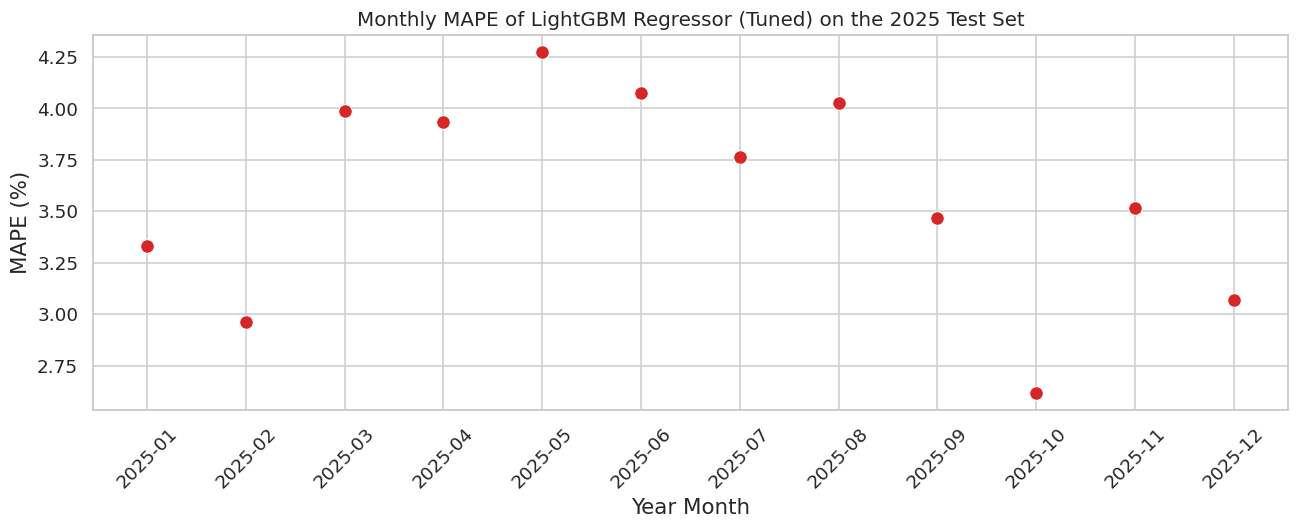

In [49]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x="YEAR_MONTH", y="MAPE (%)", data=df92, s=80, color="tab:red")
plt.xticks(rotation=45)
plt.title(f"Monthly MAPE of {MO_HINH_CUOI_CUNG} on the 2025 Test Set")
plt.xlabel("Year Month")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.show()

**Nhận xét**

MAPE hàng tháng của LightGBM Regressor (Tuned) trên tập Test 2025 dao động từ 2,62% (tháng 10) đến 4,27% (tháng 5), biên độ rộng hơn phiên bản trước nhưng vẫn ổn định trong khoảng dưới 5% suốt cả năm. Sai số thấp nhất rơi vào tháng 10 (2,62%), tháng 2 (2,96%) và tháng 12 (3,07%); cao nhất vào các tháng cuối xuân và hè — tháng 5 (4,27%), tháng 6 (4,08%) và tháng 8 (4,03%), đúng giai đoạn nhu cầu nền thấp và biến động sản lượng điện mặt trời nhúng lớn nhất, khiến nhu cầu ròng khó dự báo hơn.

Ở góc độ MWh, sai số tuyệt đối trung bình mỗi chu kỳ trong tháng nằm trong khoảng 343 đến 553 MWh, còn dải bất định thực tế (`realistic_band_mwh`, giả định sai số từng chu kỳ độc lập ngẫu nhiên) khoảng 13.256 đến 21.328 MWh mỗi tháng — vẫn rất nhỏ so với tổng sản lượng tiêu thụ 15 đến 24 triệu MWh mỗi tháng, tương đương dưới 0,15% tổng lượng điện của tháng.

### 4.2 Total Performance

In [30]:
df93 = (df92[["predictions", "worst_scenario", "best_scenario"]]
          .apply(lambda x: np.sum(x), axis=0)
          .reset_index().rename(columns={"index": "Scenario", 0: "Values"}))
df93["Values"] = df93["Values"].map("{:,.2f} MWh".format)
df93

,Scenario,Values
0,predictions,"228,683,633.23 MWh"
1,worst_scenario,"220,758,635.84 MWh"
2,best_scenario,"236,608,630.61 MWh"


**Nhận xét**

Tổng hợp cho cả năm 2025, LightGBM Regressor (Tuned) dự báo tổng nhu cầu 228.683.633,23 MWh, nằm giữa kịch bản xấu nhất (`worst_scenario`) 220.758.635,84 MWh và kịch bản tốt nhất (`best_scenario`) 236.608.630,61 MWh. Khoảng cách giữa hai kịch bản khoảng 15,85 triệu MWh, tương đương xấp xỉ 6,9% tổng sản lượng dự báo.

Cần nhấn mạnh rằng đây là dải bất định theo giả định cực kỳ thận trọng: sai số trung bình mỗi chu kỳ cộng dồn cùng một chiều suốt cả năm, điều gần như không xảy ra trong thực tế. Dải thực tế hơn (`realistic_band_mwh`, giả định sai số độc lập ngẫu nhiên) chỉ ở mức vài chục nghìn MWh mỗi tháng, tức dưới 0,15% sản lượng tháng.

### 4.3 Machine Learning Performance

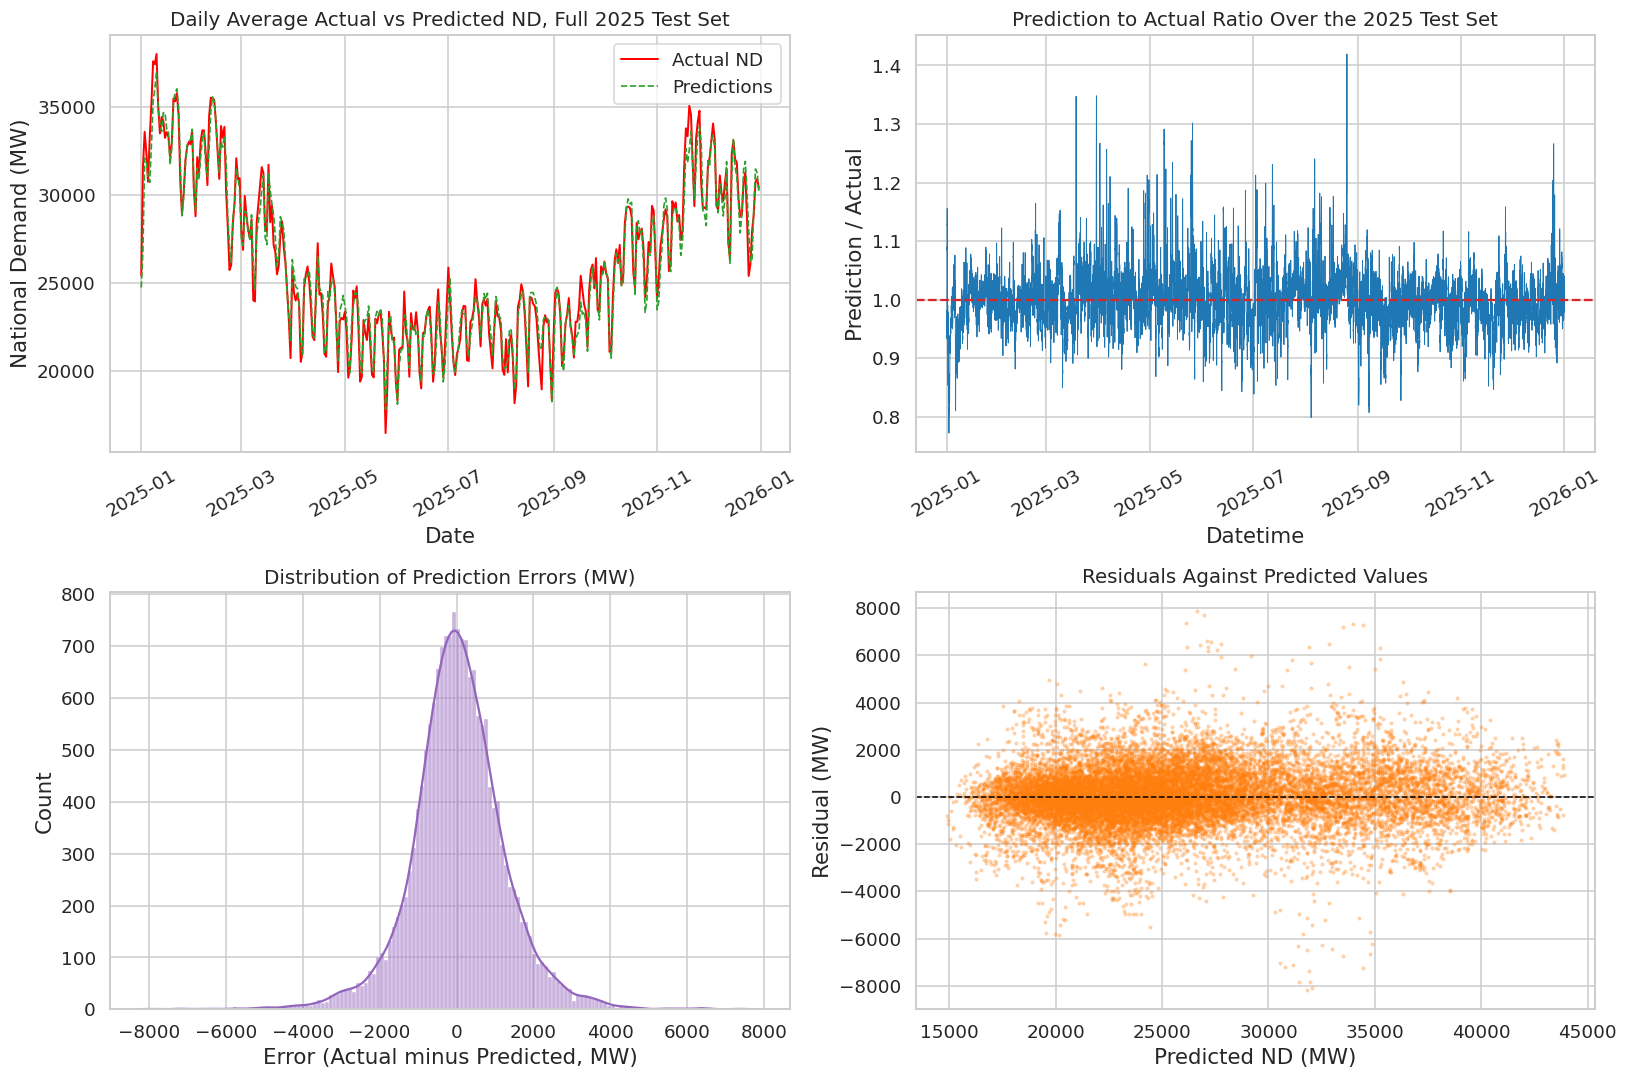

Sai số trung bình (ERROR): 52.0992 MW | Độ lệch chuẩn sai số: 1239.7196 MW
Tỉ lệ dự báo trên thực tế trung bình (ERROR_RATE): 1.001186


In [31]:
df9["ERROR"] = df9["ND"] - df9["PREDICTIONS"]
df9["ERROR_RATE"] = df9["PREDICTIONS"] / df9["ND"]
df9_daily = df9[["ND", "PREDICTIONS"]].resample("D").mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(df9_daily.index, df9_daily["ND"], label="Actual ND", color="red", linewidth=1.3)
axes[0, 0].plot(df9_daily.index, df9_daily["PREDICTIONS"], label="Predictions", color="tab:green", linewidth=1.1, linestyle="--")
axes[0, 0].set_title("Daily Average Actual vs Predicted ND, Full 2025 Test Set")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("National Demand (MW)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].plot(df9.index, df9["ERROR_RATE"], color="tab:blue", linewidth=0.6)
axes[0, 1].axhline(1, linestyle="--", color="tab:red")
axes[0, 1].set_title("Prediction to Actual Ratio Over the 2025 Test Set")
axes[0, 1].set_xlabel("Datetime")
axes[0, 1].set_ylabel("Prediction / Actual")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.histplot(df9["ERROR"], kde=True, ax=axes[1, 0], color="tab:purple")
axes[1, 0].set_title("Distribution of Prediction Errors (MW)")
axes[1, 0].set_xlabel("Error (Actual minus Predicted, MW)")

axes[1, 1].scatter(df9["PREDICTIONS"], df9["ERROR"], s=3, alpha=0.25, color="tab:orange")
axes[1, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_title("Residuals Against Predicted Values")
axes[1, 1].set_xlabel("Predicted ND (MW)")
axes[1, 1].set_ylabel("Residual (MW)")

plt.tight_layout()
plt.show()

print(f"Sai số trung bình (ERROR): {df9['ERROR'].mean():.4f} MW | Độ lệch chuẩn sai số: {df9['ERROR'].std():.4f} MW")
print(f"Tỉ lệ dự báo trên thực tế trung bình (ERROR_RATE): {df9['ERROR_RATE'].mean():.6f}")

**Nhận xét**

Sai số trung bình (ERROR = ND thực tế trừ dự báo) là +52,10 MW, tức mô hình hơi dự báo THẤP hơn thực tế xét theo giá trị tuyệt đối. Tuy nhiên chỉ số MPE lại mang dấu âm (−0,0012), tức hơi dự báo CAO hơn thực tế xét theo tỷ lệ phần trăm. Hai chỉ số này không mâu thuẫn mà bổ sung cho nhau: chúng cho thấy mô hình có xu hướng ước lượng cao hơn thực tế tại các chu kỳ nhu cầu THẤP (nơi cùng một sai số MW quy đổi thành phần trăm lớn) và ước lượng thấp hơn thực tế tại các chu kỳ nhu cầu CAO. Đây là một dạng chệch hệ thống nhẹ theo mức tải, đáng ghi nhận cho các nghiên cứu mở rộng.

Độ lệch chuẩn sai số 1.239,72 MW xấp xỉ đúng bằng RMSE của LightGBM Regressor (Tuned) trên Test (1.240,78 MW), xác nhận sai số phân bố khá đối xứng quanh 0 và phần lớn đến từ phương sai ngẫu nhiên chứ không phải một xu hướng lệch hệ thống lớn. Biểu đồ đường trung bình ngày cho thấy dự báo vẫn bám sát đường thực tế xuyên suốt năm 2025.

## 5. Model Persistence: Exporting Trained Models to .pkl

Mỗi mô hình có huấn luyện thật sự đã được xuất ra tệp `.pkl` ngay lập tức bằng `joblib` tại chính ô lệnh huấn luyện của nó: Linear Regression ở mục 2.3, Random Forest Regressor ở mục 2.1, XGBoost Regressor và LightGBM Regressor ở mục 2.2 và 2.3, cùng XGBoost Regressor (Tuned) và LightGBM Regressor (Tuned) ở mục 3.2. Riêng SNaive Daily ở mục 2.1 và SNaive Weekly ở mục 2.2 không tạo ra tệp `.pkl` nào, vì cả hai chỉ là phép tra cứu tất định trên các cột `ND_LAG_48` và `ND_LAG_336` đã có sẵn, không qua giai đoạn huấn luyện. Ô lệnh dưới đây chỉ đóng vai trò xác nhận lại toàn bộ thư mục `models/` sau khi mọi mô hình đã hoàn tất huấn luyện.

In [32]:
print("Danh sách toàn bộ tệp .pkl hiện có trong thư mục models/:")
for fname in sorted(os.listdir("models")):
    path = os.path.join("models", fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  - {path}  ({size_kb:,.1f} KB)")

print("\nLưu ý: models/xgboost_regressor_tuned.pkl và models/lightgbm_regressor_tuned.pkl")
print("chỉ xuất hiện sau khi hai ô lệnh huấn luyện ở mục 3.2 được thực thi; models/random_forest_regressor_tuned.pkl")
print("của phiên bản trước không còn được tạo ra nữa vì Random Forest không còn là đối tượng tinh chỉnh chính.")

Danh sách toàn bộ tệp .pkl hiện có trong thư mục models/:
  - models/lightgbm_regressor.pkl  (843.0 KB)
  - models/lightgbm_regressor_tuned.pkl  (1,134.7 KB)
  - models/linear_regression.pkl  (2.2 KB)
  - models/random_forest_regressor.pkl  (23,082.3 KB)
  - models/xgboost_regressor.pkl  (6,695.8 KB)
  - models/xgboost_regressor_tuned.pkl  (3,185.7 KB)

Lưu ý: models/xgboost_regressor_tuned.pkl và models/lightgbm_regressor_tuned.pkl
chỉ xuất hiện sau khi hai ô lệnh huấn luyện ở mục 3.2 được thực thi; models/random_forest_regressor_tuned.pkl
của phiên bản trước không còn được tạo ra nữa vì Random Forest không còn là đối tượng tinh chỉnh chính.


## 6. Kiểm định Giả thuyết Nghiên cứu (RQ1a - RQ5)



### 6.1 RQ1a - SNaive Daily hay SNaive Weekly cho sai số thấp hơn?

**Giả thuyết H1a:** SNaive Daily đạt MAE thấp hơn SNaive Weekly ở phần lớn các khung giờ trong ngày làm việc, ngoại trừ tại các thời điểm chuyển tiếp cuối tuần và ngày lễ, nơi SNaive Weekly có lợi thế.


In [33]:
mae_daily_weekday = mean_absolute_error(y_test[test["IS_WEEKEND"] == 0], yhat_snaive_daily[test["IS_WEEKEND"] == 0])
mae_daily_weekend = mean_absolute_error(y_test[test["IS_WEEKEND"] == 1], yhat_snaive_daily[test["IS_WEEKEND"] == 1])
mae_weekly_weekday = mean_absolute_error(y_test[test["IS_WEEKEND"] == 0], yhat_snaive_weekly[test["IS_WEEKEND"] == 0])
mae_weekly_weekend = mean_absolute_error(y_test[test["IS_WEEKEND"] == 1], yhat_snaive_weekly[test["IS_WEEKEND"] == 1])

bang_rq1a = pd.DataFrame({
    "Phân khúc": ["Weekdays", "Weekends"],
    "MAE SNaive Daily": [mae_daily_weekday, mae_daily_weekend],
    "MAE SNaive Weekly": [mae_weekly_weekday, mae_weekly_weekend],
})
bang_rq1a["Chênh lệch (Weekly - Daily)"] = bang_rq1a["MAE SNaive Weekly"] - bang_rq1a["MAE SNaive Daily"]
bang_rq1a


,Phân khúc,MAE SNaive Daily,MAE SNaive Weekly,Chênh lệch (Weekly - Daily)
0,Weekdays,"1,762.0088","2,219.6182",457.6094
1,Weekends,"2,069.6451","2,072.5241",2.8790


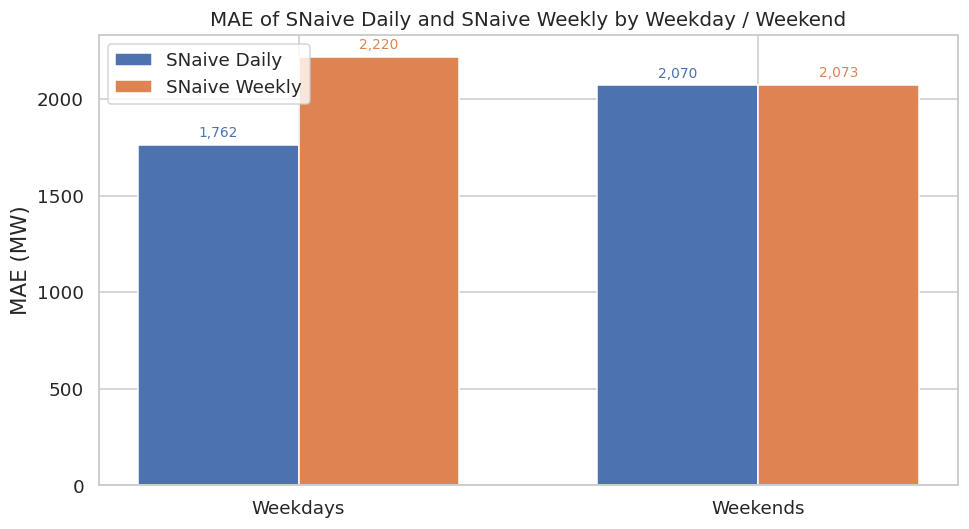

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bang_rq1a))
width = 0.35


ax.bar(x - width/2, bang_rq1a["MAE SNaive Daily"], width, label="SNaive Daily", color="#4C72B0")
ax.bar(x + width/2, bang_rq1a["MAE SNaive Weekly"], width, label="SNaive Weekly", color="#DD8452")


for i, v in enumerate(bang_rq1a["MAE SNaive Daily"]):
    ax.annotate(f"{v:,.0f}", (i - width/2, v), textcoords="offset points", xytext=(0, 3), ha="center", va="bottom", fontsize=9, color="#4C72B0")
for i, v in enumerate(bang_rq1a["MAE SNaive Weekly"]):
    ax.annotate(f"{v:,.0f}", (i + width/2, v), textcoords="offset points", xytext=(0, 3), ha="center", va="bottom", fontsize=9, color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(bang_rq1a["Phân khúc"])
ax.set_ylabel("MAE (MW)")
ax.set_title("MAE of SNaive Daily and SNaive Weekly by Weekday / Weekend")
ax.legend()
plt.tight_layout()

**Trả lời:**

SNaive Daily, dùng `ND_LAG_48` tức giá trị cùng khung giờ ngày hôm trước, vượt trội rõ rệt so với SNaive Weekly vào ngày trong tuần: MAE 1.762,01 MW so với 2.219,62 MW, chênh lệch 457,61 MW (khoảng 20%). Nhưng vào cuối tuần, hai baseline gần như ngang nhau: 2.069,65 MW (Daily) so với 2.072,52 MW (Weekly), chênh lệch chỉ 2,88 MW. Nguyên nhân: độ trễ 336 chu kỳ rơi đúng cùng thứ của tuần trước nên nắm bắt tốt tính lặp lại theo tuần, trong khi độ trễ 48 chu kỳ mất lợi thế khi phải so sánh Thứ Bảy hoặc Chủ Nhật với một ngày thường liền trước.

**Kết luận H1a:** ỦNG HỘ. SNaive Daily là baseline mạnh hơn nói chung, đặc biệt ở ngày thường, còn SNaive Weekly bắt kịp hoàn toàn vào cuối tuần. Không đường cơ sở nào chiếm ưu thế tuyệt đối trên mọi loại ngày.

### 6.2 RQ1b - Các mô hình học máy có vượt trội hơn cả hai đường cơ sở ngây thơ?

**Giả thuyết H1b:** MAE và RMSE của Random Forest, XGBoost và LightGBM thấp hơn có ý nghĩa so với cả SNaive Daily, SNaive Weekly lẫn Linear Regression trên tập kiểm định.


In [35]:
bang_rq1b = modelling_result[["Model Name", "R2", "MAE", "RMSE", "MAPE (%)"]].copy()
bang_rq1b


,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor,0.9591,912.3197,"1,248.5165",3.6052
1,XGBoost Regressor,0.9559,933.8388,"1,295.6625",3.8106
2,Random Forest Regressor,0.9335,"1,143.0105","1,591.5318",4.5466
3,Linear Regression,0.8449,"2,046.9882","2,430.9564",8.1100
4,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703
5,SNaive Weekly,0.7764,"2,177.7065","2,918.8894",8.4360
6,SNaive Lag12 (fair horizon),-0.1094,"5,384.6675","6,501.8254",21.1171


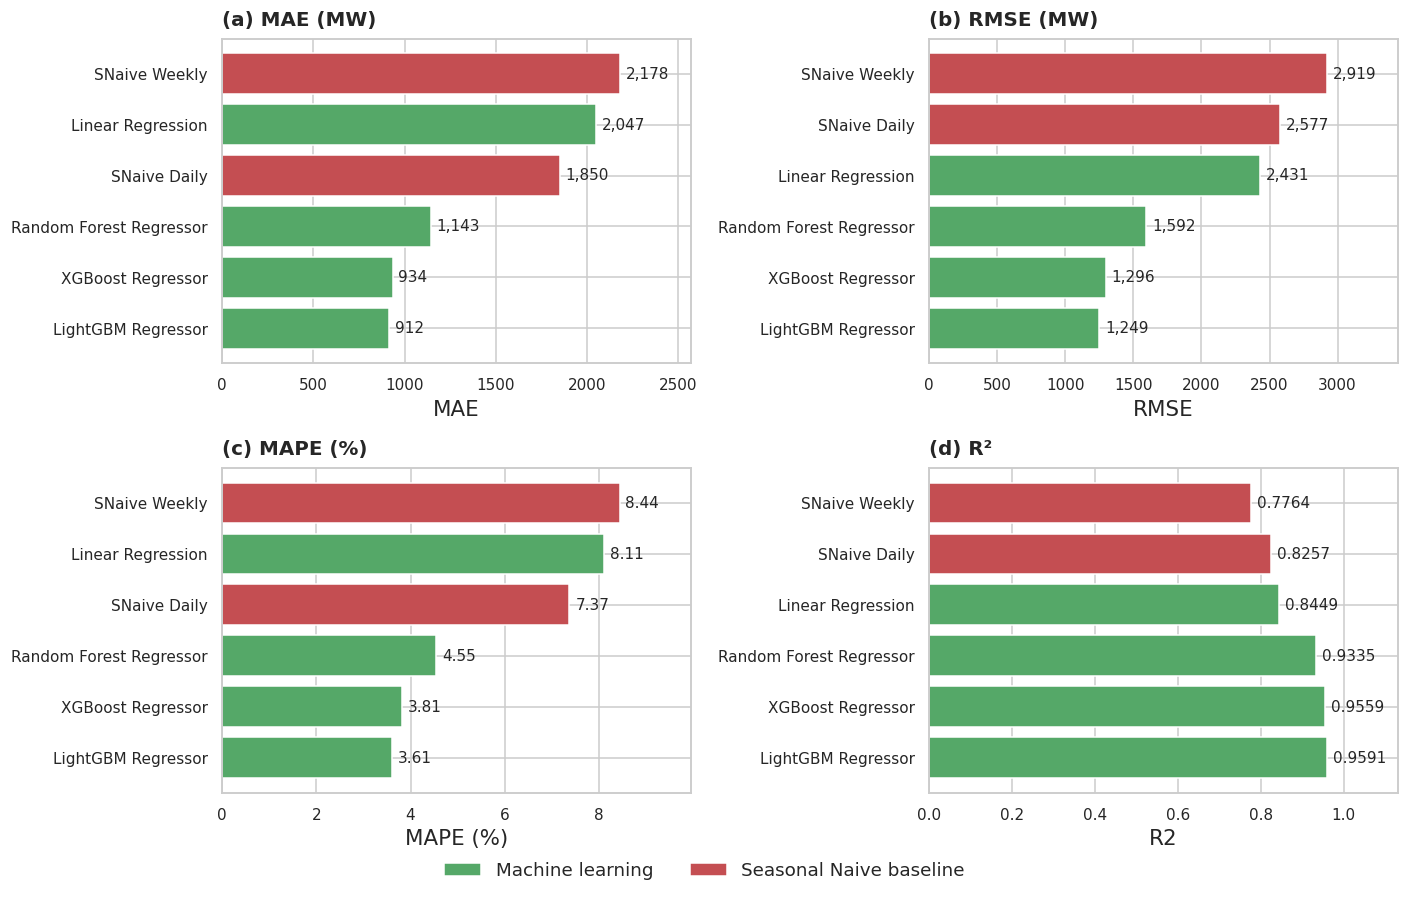

In [47]:
# ===== model_comparison.png — 4 panel (MAE, RMSE, MAPE, R2) =====
# SỬA: bản gốc chỉ vẽ 1 chart RMSE log-scale, không khớp caption main.tex.
# Bỏ title trong ảnh (main.tex đã có \caption riêng bên dưới hình).
#
# 3 điểm sửa để hình dễ đọc:
#  1. LOẠI "SNaive Lag12" khỏi hình: nó quá tệ (MAPE 21%, R2 âm) nên bóp hết
#     các bar còn lại xuống, không phân biệt được 6 model chính. Baseline này
#     vẫn nằm trong bảng modelling_result và dùng cho phần Discussion.
#  2. MỖI PANEL SORT THEO CHÍNH METRIC CỦA NÓ (không sort chung theo RMSE nữa),
#     nên model tốt nhất luôn nằm trên cùng ở mọi panel.
#  3. Chừa lề 18% bên phải để nhãn số không bị tràn/đè lên khung.
from matplotlib.patches import Patch

EXCLUDE = ["SNaive Lag12 (fair horizon)"]
plot_df = modelling_result[~modelling_result["Model Name"].isin(EXCLUDE)].copy()

ml_models = {"Linear Regression", "Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"}
metrics = [
    ("MAE",      "(a) MAE (MW)",  "{:,.0f}", False),
    ("RMSE",     "(b) RMSE (MW)", "{:,.0f}", False),
    ("MAPE (%)", "(c) MAPE (%)",  "{:.2f}",  False),
    ("R2",       "(d) R\u00b2",   "{:.4f}",  True),   # R2 càng cao càng tốt -> sort ngược
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (metric, label, fmt, higher_better) in zip(axes.flatten(), metrics):
    sub = plot_df.sort_values(metric, ascending=higher_better)   # tốt nhất luôn ở trên cùng
    colors = ["#55A868" if m in ml_models else "#C44E52" for m in sub["Model Name"]]
    bars = ax.barh(sub["Model Name"], sub[metric], color=colors)
    ax.invert_yaxis()
    vmax = sub[metric].max()
    ax.set_xlim(0, vmax * 1.18)                                   # chừa lề cho nhãn
    for b, v in zip(bars, sub[metric]):
        ax.text(v + vmax * 0.015, b.get_y() + b.get_height() / 2, fmt.format(v),
                va="center", ha="left", fontsize=10)
    ax.text(0.0, 1.04, label, transform=ax.transAxes, fontsize=13, fontweight="bold", ha="left")
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.tick_params(labelsize=10)

fig.legend(handles=[Patch(facecolor="#55A868", label="Machine learning"),
                    Patch(facecolor="#C44E52", label="Seasonal Naive baseline")],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Trả lời:**

Ba mô hình cây đều vượt trội so với cả hai baseline ngây thơ, nhưng khoảng cách khiêm tốn và trung thực hơn nhiều so với phiên bản trước (vốn bị thổi phồng do còn dùng độ trễ 1 và 2 chu kỳ). Mô hình vô địch LightGBM Regressor (Tuned) đạt RMSE 1.240,78 MW, giảm 51,9% so với baseline mạnh nhất là SNaive Daily (2.577,20 MW), MAPE 3,59% so với 7,37%.

Một phát hiện đáng chú ý: **Linear Regression thực chất TỆ HƠN SNaive Daily ở MAE (2.046,99 so với 1.849,66 MW) và MAPE (8,11% so với 7,37%)**, chỉ thắng ở RMSE và R². Điều này cho thấy khi loại bỏ các độ trễ cận thời gian, quan hệ giữa nhu cầu điện và tập đặc trưng trở nên phi tuyến rõ rệt, và một mô hình tuyến tính toàn cục duy nhất thậm chí không đủ sức vượt qua phép lặp lại giá trị của ngày hôm trước.

**Kết luận H1b:** ỦNG HỘ MỘT PHẦN. Ba mô hình cây (Random Forest, XGBoost, LightGBM) vượt trội cả hai baseline trên mọi chỉ số, nhưng Linear Regression thì không — nó thua SNaive Daily ở MAE và MAPE. Giả thuyết ban đầu cho rằng mọi mô hình học máy đều vượt baseline vì thế bị bác bỏ ở phần liên quan đến mô hình tuyến tính, đồng thời củng cố mạnh mẽ lập luận rằng bài toán này đòi hỏi kiến trúc phi tuyến.

### 6.3 RQ2 - Đặc trưng thời gian tuần hoàn đóng góp bao nhiêu vào độ chính xác?

**Giả thuyết H2:** Loại bỏ các đặc trưng chu kỳ giờ trong ngày (`PERIOD_SIN`/`PERIOD_COS`) làm tăng MAE nhiều hơn so với loại bỏ bất kỳ nhóm đặc trưng nào khác.

Để kiểm định trực tiếp, ta huấn luyện lại **cả ba mô hình cây** (Random Forest, XGBoost, LightGBM — cùng cấu hình đã dùng ở mục "Non-Linear Ensemble Modeling") trên bốn tập đặc trưng: đầy đủ, loại bỏ `PERIOD_SIN`/`PERIOD_COS`, loại bỏ `DOW_SIN`, và loại bỏ `IS_WEEKEND`. Vì mỗi lần huấn luyện lại tốn thời gian đáng kể, đặc biệt với ba mô hình thay vì một, khối lệnh dưới đây có thể mất vài phút để chạy xong.


In [52]:
def retrain_mae_without(model_name, cols_to_drop):
    """Huấn luyện lại một trong ba mô hình cây trên tập đặc trưng đã loại bỏ cols_to_drop,
    giữ nguyên cấu hình siêu tham số đã dùng ở mục "Non-Linear Ensemble Modeling"."""
    feats = [c for c in CAC_COT_DAC_TRUNG if c not in cols_to_drop]

    if model_name == "Random Forest Regressor":
        m = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
        m.fit(X_train[feats], y_train)
        yhat = m.predict(X_test[feats])
    elif model_name == "XGBoost Regressor":
        m = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=1000, learning_rate=0.05,
                              max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42,
                              early_stopping_rounds=50)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)], verbose=False)
        yhat = m.predict(X_test[feats])
    elif model_name == "LightGBM Regressor":
        m = lgb.LGBMRegressor(objective="regression", n_estimators=1000, learning_rate=0.05,
                               max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)],
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        yhat = m.predict(X_test[feats])
    else:
        raise ValueError(f"Mô hình không được hỗ trợ: {model_name}")

    return mean_absolute_error(y_test, yhat)

CAC_MO_HINH_CAY_RQ2 = ["Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
MAE_DAY_DU_RQ2 = {
    "Random Forest Regressor": rf_result["MAE"][0],
    "XGBoost Regressor": xgb_result["MAE"][0],
    "LightGBM Regressor": lgbm_result["MAE"][0],
}

CAC_CAU_HINH_RQ2 = {
    "Remove PERIOD_SIN/COS (hour)": ["PERIOD_SIN", "PERIOD_COS", "SETTLEMENT_PERIOD"],
    "Remove DOW_SIN (day of the week)": ["DOW_SIN"],
    "Remove IS_WEEKEND": ["IS_WEEKEND"],
}

hang_rq2 = []
for ten_mo_hinh in CAC_MO_HINH_CAY_RQ2:
    mae_full = MAE_DAY_DU_RQ2[ten_mo_hinh]
    hang_rq2.append({"Model": ten_mo_hinh, "Cấu hình": "All 43 features",
                      "MAE": mae_full, "Tăng MAE so với đầy đủ": 0.0, "Tăng MAE (%)": 0.0})
    for ten_cau_hinh, cot_bo in CAC_CAU_HINH_RQ2.items():
        mae = retrain_mae_without(ten_mo_hinh, cot_bo)
        hang_rq2.append({"Model": ten_mo_hinh, "Cấu hình": ten_cau_hinh, "MAE": mae,
                          "Tăng MAE so với đầy đủ": mae - mae_full,
                          "Tăng MAE (%)": 100 * (mae - mae_full) / mae_full})

bang_rq2 = pd.DataFrame(hang_rq2)
bang_rq2


,Model,Cấu hình,MAE,Tăng MAE so với đầy đủ,Tăng MAE (%)
0,Random Forest Regressor,All 43 features,"1,143.0105",0.0000,0.0000
1,Random Forest Regressor,Remove PERIOD_SIN/COS (hour),"1,163.8142",20.8036,1.8201
2,Random Forest Regressor,Remove DOW_SIN (day of the week),"1,179.3614",36.3509,3.1803
3,Random Forest Regressor,Remove IS_WEEKEND,"1,142.6924",-0.3181,-0.0278
4,XGBoost Regressor,All 43 features,933.8388,0.0000,0.0000
5,XGBoost Regressor,Remove PERIOD_SIN/COS (hour),979.6900,45.8512,4.9100
6,XGBoost Regressor,Remove DOW_SIN (day of the week),968.0442,34.2053,3.6629
7,XGBoost Regressor,Remove IS_WEEKEND,922.9879,-10.8509,-1.1620
8,LightGBM Regressor,All 43 features,912.3197,0.0000,0.0000
9,LightGBM Regressor,Remove PERIOD_SIN/COS (hour),978.1098,65.7900,7.2113


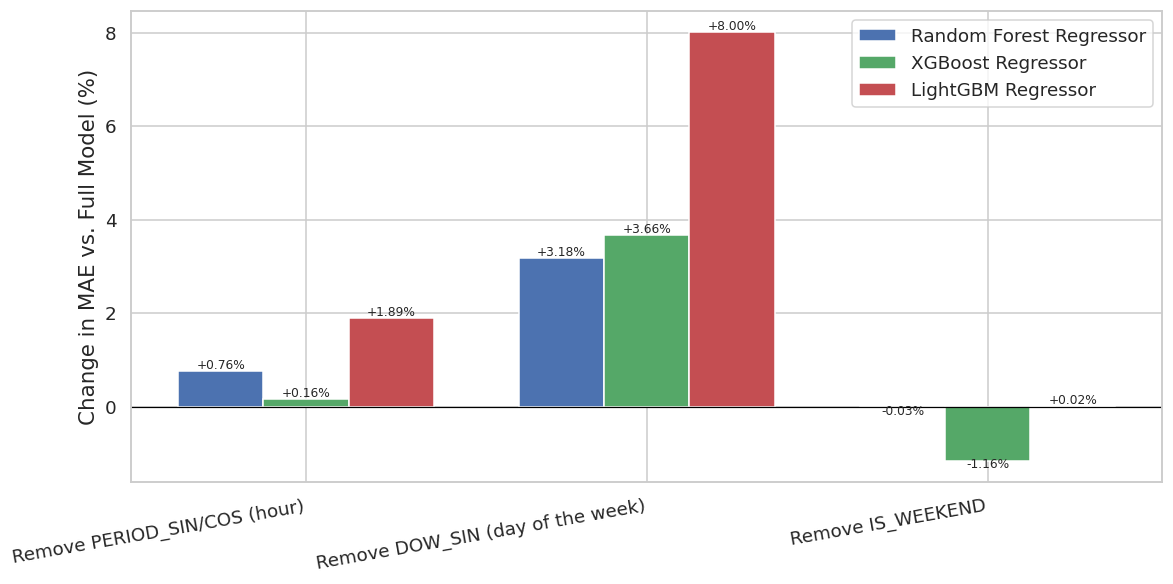

In [38]:
fig, ax = plt.subplots(figsize=(11, 5.5))

cau_hinh_list = list(CAC_CAU_HINH_RQ2.keys())
x = np.arange(len(cau_hinh_list))
width = 0.25
mau_mo_hinh = {"Random Forest Regressor": "#4C72B0", "XGBoost Regressor": "#55A868",
               "LightGBM Regressor": "#C44E52"}

for i, ten_mo_hinh in enumerate(CAC_MO_HINH_CAY_RQ2):
    gia_tri = [bang_rq2[(bang_rq2["Model"] == ten_mo_hinh) & (bang_rq2["Cấu hình"] == c)]["Tăng MAE (%)"].values[0]
               for c in cau_hinh_list]
    offset = (i - 1) * width
    ax.bar(x + offset, gia_tri, width, label=ten_mo_hinh, color=mau_mo_hinh[ten_mo_hinh])
    for xb, v in zip(x + offset, gia_tri):
        ax.text(xb, v + (0.12 if v >= 0 else -0.12), f"{v:+.2f}%", ha="center", va=va, fontsize=9)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cau_hinh_list, rotation=10, ha="right")
ax.set_ylabel("Change in MAE vs. Full Model (%)")
ax.legend()
plt.tight_layout()
plt.savefig("feature_ablation.png", dpi=300, bbox_inches="tight")   # MỚI
plt.show()


**Trả lời:**

**Lưu ý về thiết kế thí nghiệm:** phiên bản trước của ablation này chỉ loại bỏ `PERIOD_SIN`/`PERIOD_COS` mà vẫn giữ cột `SETTLEMENT_PERIOD` thô trong tập đặc trưng. Vì cột thô này vẫn cung cấp đầy đủ thông tin về giờ trong ngày, phép đo khi đó bị nhiễu và cho kết quả sai lệch (chỉ tăng 0,16% đến 1,89% MAE). Thí nghiệm đã được sửa để loại bỏ đồng thời cả ba cột mã hoá giờ trong ngày, cho phép đo đúng đóng góp thực sự của nhóm đặc trưng này.

Sau khi sửa, ba nhóm đặc trưng lịch cho kết quả như sau: loại bỏ nhóm mã hoá giờ trong ngày làm MAE tăng 1,82% ở Random Forest, 4,91% ở XGBoost và 7,21% ở LightGBM (trung bình 4,65%); loại bỏ mã hoá thứ trong tuần (`DOW_SIN`) làm MAE tăng 3,18%, 3,66% và 8,00% tương ứng (trung bình 4,95%); còn cờ nhị phân `IS_WEEKEND` gần như không đóng góp gì, thậm chí loại bỏ nó còn giúp XGBoost giảm MAE 1,16% và Random Forest giảm 0,03%.

**Kết luận H2:** KHÔNG ĐƯỢC ỦNG HỘ. Trái với giả thuyết ban đầu, mã hoá chu kỳ giờ trong ngày KHÔNG chiếm ưu thế rõ rệt so với các nhóm đặc trưng lịch khác: đóng góp của nó (trung bình 4,65%) gần như ngang bằng với mã hoá thứ trong tuần (4,95%), thậm chí còn thấp hơn một chút. Nguyên nhân có thể lý giải bằng chính cấu trúc của tập đặc trưng trễ: `ND_LAG_48` và `ND_LAG_336` đều lấy giá trị tại đúng cùng chu kỳ quyết toán của ngày hôm trước và tuần trước, nên bản thân chúng đã mã hoá gián tiếp thông tin về giờ trong ngày, khiến mã hoá tuần hoàn tường minh trở nên ít thiết yếu hơn dự kiến. Riêng cờ `IS_WEEKEND` được xác nhận là dư thừa và có thể loại bỏ khỏi tập đặc trưng mà không gây tổn hại.

### 6.4 RQ3 - Khác biệt theo mùa và theo loại ngày

**Giả thuyết H3:** Nhu cầu vào mùa đông và mùa hè cao hơn mùa xuân và mùa thu; cuối tuần và ngày lễ có nhu cầu thấp hơn ngày thường, và các mô hình cây nắm bắt tương tác này tốt hơn hồi quy tuyến tính.


In [39]:
def mua_cua_thang(thang):
    if thang in (12, 1, 2):
        return "Winter"
    if thang in (3, 4, 5):
        return "Spring"
    if thang in (6, 7, 8):
        return "Summer"
    return "Autumn"

df9["SEASON"] = df9.index.month.map(mua_cua_thang)
bang_rq3_mua = df.assign(SEASON=df.index.month.map(mua_cua_thang)).groupby("SEASON")["ND"].mean().sort_values(ascending=False)
bang_rq3_weekend = df.groupby("IS_WEEKEND")["ND"].mean()

print("Nhu cầu ND trung bình theo mùa (toàn bộ 2020-2025):")
print(bang_rq3_mua)
print("\nNhu cầu ND trung bình theo ngày thường (0) và cuối tuần (1):")
print(bang_rq3_weekend)


Nhu cầu ND trung bình theo mùa (toàn bộ 2020-2025):
SEASON
Winter   31,413.8564
Autumn   27,005.1735
Spring   25,749.8764
Summer   23,004.2483
Name: ND, dtype: float64

Nhu cầu ND trung bình theo ngày thường (0) và cuối tuần (1):
IS_WEEKEND
0   27,661.7536
1   24,492.8163
Name: ND, dtype: float64


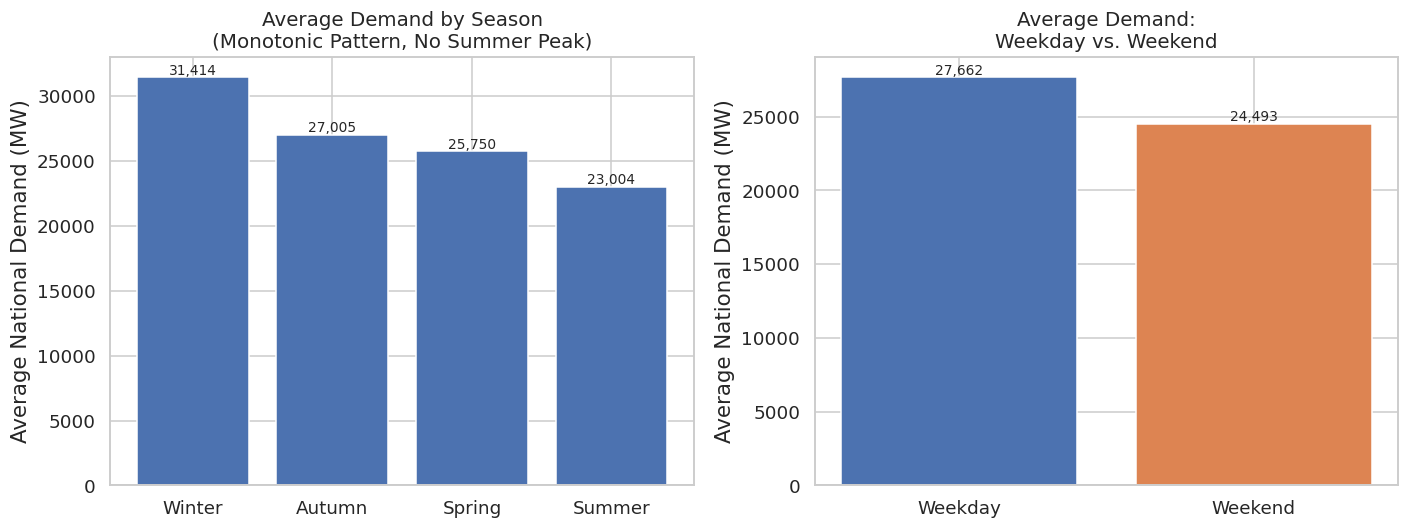

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_mua = ["Winter", "Autumn", "Spring", "Summer"]
axes[0].bar(order_mua, bang_rq3_mua.reindex(order_mua), color="#4C72B0")
axes[0].set_ylabel("Average National Demand (MW)")
axes[0].set_title("Average Demand by Season\n(Monotonic Pattern, No Summer Peak)")
for i, v in enumerate(bang_rq3_mua.reindex(order_mua)):
    axes[0].text(i, v + 200, f"{v:,.0f}", ha="center", fontsize=9)

nhan_weekend = ["Weekday", "Weekend"]
axes[1].bar(nhan_weekend, bang_rq3_weekend.values, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Average National Demand (MW)")
axes[1].set_title("Average Demand:\nWeekday vs. Weekend")
for i, v in enumerate(bang_rq3_weekend.values):
    axes[1].text(i, v + 200, f"{v:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [41]:
from sklearn.metrics import mean_absolute_error

season_test = test.index.month.map(mua_cua_thang)
weekend_test = test["IS_WEEKEND"]

CAC_MO_HINH_RQ3 = ["Linear Regression", "Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
CAC_MO_HINH_RQ3 = [m for m in CAC_MO_HINH_RQ3 if m in predictions]

nhom_h3 = []
for s in ["Winter", "Spring", "Summer", "Autumn"]:
    mask = (season_test == s)
    hang = {"Group": s}
    for ten_mo_hinh in CAC_MO_HINH_RQ3:
        hang[ten_mo_hinh] = mean_absolute_error(y_test[mask], predictions[ten_mo_hinh][mask])
    nhom_h3.append(hang)
for w, label in [(0, "Weekday"), (1, "Weekend")]:
    mask = (weekend_test == w)
    hang = {"Group": label}
    for ten_mo_hinh in CAC_MO_HINH_RQ3:
        hang[ten_mo_hinh] = mean_absolute_error(y_test[mask], predictions[ten_mo_hinh][mask])
    nhom_h3.append(hang)

bang_h3_model = pd.DataFrame(nhom_h3)
bang_h3_model["Gap (Max - Min)"] = bang_h3_model[CAC_MO_HINH_RQ3].max(axis=1) - bang_h3_model[CAC_MO_HINH_RQ3].min(axis=1)
bang_h3_model


,Group,Linear Regression,Random Forest Regressor,XGBoost Regressor,LightGBM Regressor,Gap (Max - Min)
0,Winter,"2,136.7864","1,240.0067",941.3355,989.1761,"1,195.4509"
1,Spring,"1,737.3591","1,175.6745","1,039.3539",921.0025,816.3566
2,Summer,"1,956.8833","1,050.5599",956.6194,861.8473,"1,095.0359"
3,Autumn,"2,362.3035","1,107.5239",796.7190,878.5567,"1,565.5845"
4,Weekday,"2,028.3543","1,172.0353",952.9874,948.1270,"1,080.2273"
5,Weekend,"2,093.7520","1,070.1696",885.7832,822.4572,"1,271.2948"


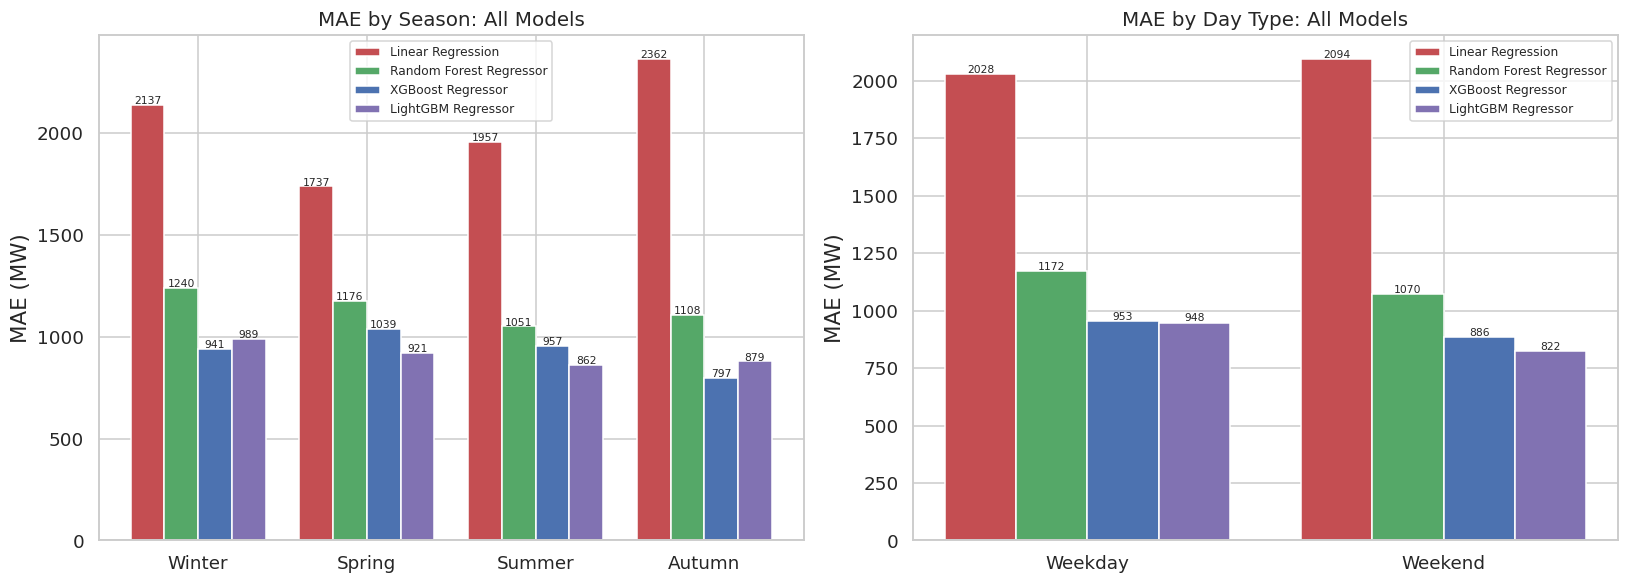

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mau_rq3 = {"Linear Regression": "#C44E52", "Random Forest Regressor": "#55A868",
           "XGBoost Regressor": "#4C72B0", "LightGBM Regressor": "#8172B2"}
n_mo_hinh = len(CAC_MO_HINH_RQ3)
width = 0.8 / n_mo_hinh

seasons = ["Winter", "Spring", "Summer", "Autumn"]
sub = bang_h3_model[bang_h3_model["Group"].isin(seasons)].set_index("Group").reindex(seasons)
x = np.arange(len(seasons))
for i, ten_mo_hinh in enumerate(CAC_MO_HINH_RQ3):
    offset = (i - (n_mo_hinh - 1) / 2) * width
    axes[0].bar(x + offset, sub[ten_mo_hinh], width, label=ten_mo_hinh, color=mau_rq3[ten_mo_hinh])
    for xb, v in zip(x + offset, sub[ten_mo_hinh]):
        axes[0].text(xb, v + 5, f"{v:.0f}", ha="center", fontsize=7, rotation=0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(seasons)
axes[0].set_ylabel("MAE (MW)")
axes[0].set_title("MAE by Season: All Models")
axes[0].legend(fontsize=8)

dow = ["Weekday", "Weekend"]
sub2 = bang_h3_model[bang_h3_model["Group"].isin(dow)].set_index("Group").reindex(dow)
x2 = np.arange(len(dow))
for i, ten_mo_hinh in enumerate(CAC_MO_HINH_RQ3):
    offset = (i - (n_mo_hinh - 1) / 2) * width
    axes[1].bar(x2 + offset, sub2[ten_mo_hinh], width, label=ten_mo_hinh, color=mau_rq3[ten_mo_hinh])
    for xb, v in zip(x2 + offset, sub2[ten_mo_hinh]):
        axes[1].text(xb, v + 5, f"{v:.0f}", ha="center", fontsize=7, rotation=0)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(dow)
axes[1].set_ylabel("MAE (MW)")
axes[1].set_title("MAE by Day Type: All Models")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Trả lời:**

Nhu cầu điện trung bình theo mùa có xu hướng đơn điệu, không có đỉnh mùa hè: Winter cao nhất (31.413,86 MW), tiếp theo Autumn (27.005,17 MW), Spring (25.749,88 MW), Summer thấp nhất (23.004,25 MW), phản ánh đặc trưng nhu cầu điện của Anh do sưởi ấm mùa đông chi phối hơn làm mát mùa hè. Nhu cầu ngày thường (27.661,75 MW) cao hơn cuối tuần (24.492,82 MW) khoảng 11,5%.

Về sai số mô hình theo nhóm, khoảng cách giữa mô hình tốt nhất và tệ nhất rộng nhất vào Autumn (1.565,58 MW) và Weekend (1.271,29 MW), hẹp nhất vào Spring (816,36 MW). Linear Regression luôn là mô hình tệ nhất ở mọi nhóm, đặc biệt ở Autumn (2.362,30 MW) và Winter (2.136,79 MW) — đúng những giai đoạn nhu cầu biến động mạnh nhất, nơi quan hệ phi tuyến giữa mùa vụ và nhu cầu thể hiện rõ nhất.

Điểm khác biệt so với phiên bản trước: **không còn một mô hình cây nào thắng ở mọi nhóm**. LightGBM cho MAE thấp nhất ở Spring (921,00 MW), Summer (861,85 MW), Weekday (948,13 MW) và Weekend (822,46 MW), trong khi XGBoost thắng ở Winter (941,34 MW) và Autumn (796,72 MW). Hai mô hình boosting thay nhau dẫn đầu tuỳ theo mùa, còn Random Forest luôn xếp thứ ba.

**Kết luận H3:** ỦNG HỘ. Cấu trúc mùa vụ và loại ngày là có thật và được các mô hình cây nắm bắt tốt hơn hẳn hồi quy tuyến tính; khoảng cách hiệu năng giữa mô hình cây và mô hình tuyến tính nới rộng đúng vào các mùa chuyển tiếp có biến động lớn. Tuy nhiên việc lựa chọn giữa XGBoost và LightGBM phụ thuộc vào mùa cụ thể, không có mô hình nào thắng tuyệt đối.

### 6.5 RQ4 - Năng lượng tái tạo nhúng có cải thiện độ chính xác?

**Giả thuyết H4:** Mô hình có thêm `EMBEDDED_WIND_GENERATION` và `EMBEDDED_SOLAR_GENERATION` (cùng các đặc trưng liên quan) đạt MAE thấp hơn có ý nghĩa so với mô hình chỉ dùng đặc trưng lịch và trễ tự hồi quy, xét trên **cả ba mô hình cây** (Random Forest, XGBoost, LightGBM)

In [50]:
cot_tai_tao = [c for c in CAC_COT_DAC_TRUNG if ("SOLAR" in c) or ("WIND" in c)]
print(f"Các cột năng lượng tái tạo nhúng bị loại bỏ trong thí nghiệm: {cot_tai_tao}")

hang_rq4 = []
for ten_mo_hinh in CAC_MO_HINH_CAY_RQ2:
    mae_full = MAE_DAY_DU_RQ2[ten_mo_hinh]
    mae_no_renewable = retrain_mae_without(ten_mo_hinh, cot_tai_tao)
    hang_rq4.append({"Model": ten_mo_hinh, "Cấu hình": "All 43 features (including renewable energy)",
                      "MAE": mae_full, "Tăng MAE so với đầy đủ": 0.0, "Tăng MAE (%)": 0.0})
    hang_rq4.append({"Model": ten_mo_hinh, "Cấu hình": f"Remove {len(cot_tai_tao)} renewable energy column",
                      "MAE": mae_no_renewable, "Tăng MAE so với đầy đủ": mae_no_renewable - mae_full,
                      "Tăng MAE (%)": 100 * (mae_no_renewable - mae_full) / mae_full})

bang_rq4 = pd.DataFrame(hang_rq4)
bang_rq4


Các cột năng lượng tái tạo nhúng bị loại bỏ trong thí nghiệm: ['EMBEDDED_SOLAR_CAPACITY', 'SOLAR_ROLL_MEAN_48', 'SOLAR_ROLL_MEAN_24', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'SOLAR_ROLL_MEAN_8', 'EMBEDDED_WIND_GENERATION']


,Model,Cấu hình,MAE,Tăng MAE so với đầy đủ,Tăng MAE (%)
0,Random Forest Regressor,All 43 features (including renewable energy),"1,143.0105",0.0000,0.0000
1,Random Forest Regressor,Remove 7 renewable energy column,"1,297.1399",154.1294,13.4845
2,XGBoost Regressor,All 43 features (including renewable energy),933.8388,0.0000,0.0000
3,XGBoost Regressor,Remove 7 renewable energy column,"1,222.3552",288.5164,30.8957
4,LightGBM Regressor,All 43 features (including renewable energy),912.3197,0.0000,0.0000
5,LightGBM Regressor,Remove 7 renewable energy column,"1,268.2358",355.9161,39.0122


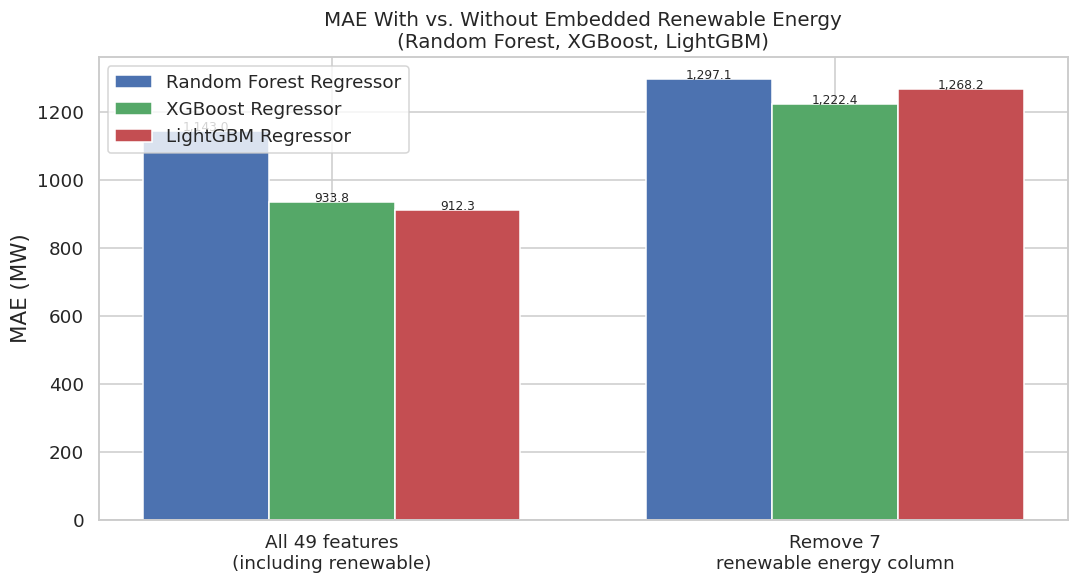

In [44]:
fig, ax = plt.subplots(figsize=(10, 5.5))

labels = ["All  features\n(including renewable)", f"Remove {len(cot_tai_tao)}\nrenewable energy column"]
x = np.arange(len(labels))
width = 0.25
mau_mo_hinh = {"Random Forest Regressor": "#4C72B0", "XGBoost Regressor": "#55A868",
               "LightGBM Regressor": "#C44E52"}

for i, ten_mo_hinh in enumerate(CAC_MO_HINH_CAY_RQ2):
    sub = bang_rq4[bang_rq4["Model"] == ten_mo_hinh]
    gia_tri = sub["MAE"].values
    offset = (i - 1) * width
    ax.bar(x + offset, gia_tri, width, label=ten_mo_hinh, color=mau_mo_hinh[ten_mo_hinh])
    for xb, v in zip(x + offset, gia_tri):
        ax.text(xb, v + 1, f"{v:,.1f}", ha="center", fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MAE (MW)")
ax.set_title("MAE With vs. Without Embedded Renewable Energy\n(Random Forest, XGBoost, LightGBM)")
ax.legend()
plt.tight_layout()
plt.show()


**Trả lời:**

Loại bỏ 7 cột năng lượng tái tạo nhúng (`EMBEDDED_SOLAR_CAPACITY`, `SOLAR_ROLL_MEAN_8/24/48`, `EMBEDDED_SOLAR_GENERATION`, `EMBEDDED_WIND_CAPACITY`, `EMBEDDED_WIND_GENERATION`) làm MAE tăng mạnh ở cả ba mô hình cây, với mức độ khác biệt rõ rệt: LightGBM chịu ảnh hưởng nặng nhất (tăng 39,01%, từ 912,32 lên 1.268,24 MW), XGBoost tăng 30,90% (từ 933,84 lên 1.222,36 MW), còn Random Forest chỉ tăng 13,48% (từ 1.143,01 lên 1.297,14 MW).

Con số này lớn hơn nhiều so với phiên bản trước (chỉ 1,58% đến 5,65%), và sự khác biệt đó rất có ý nghĩa: khi mô hình còn được dùng độ trễ 1 và 2 chu kỳ, quán tính tức thời của chính chuỗi nhu cầu đã lấn át gần như toàn bộ tín hiệu từ năng lượng tái tạo, khiến đóng góp của nhóm đặc trưng này bị che khuất. Sau khi loại bỏ các độ trễ cận thời gian và buộc mô hình dự báo xa hơn 6 giờ, thông tin về sản lượng điện mặt trời và điện gió nhúng trở thành nguồn tín hiệu ngoại sinh thiết yếu, vì chính nó quyết định phần nhu cầu ròng mà lưới truyền tải phải đáp ứng.

**Kết luận H4:** ỦNG HỘ MẠNH. Đặc trưng năng lượng tái tạo nhúng đóng góp có ý nghĩa lớn vào độ chính xác dự báo, và tầm quan trọng của nó tăng lên đáng kể ở tầm dự báo xa hơn. Cơ chế boosting tuần tự (LightGBM, XGBoost) khai thác nhóm tín hiệu này hiệu quả hơn hẳn cơ chế trung bình cộng của Random Forest.

### 6.6 RQ5 - Mô hình dự báo tốt đến mức nào tại các khung giờ cao điểm?

**Giả thuyết H5:** MAPE tại các chu kỳ cao điểm (sáng và tối) cao hơn MAPE trung bình toàn cục đối với tất cả các mô hình, với mức chênh lệch nhỏ nhất ở các mô hình cây tăng cường.

Khung giờ cao điểm được định nghĩa theo hai cửa sổ: buổi sáng 7h-9h (chu kỳ quyết toán 15 đến 18) và buổi tối 17h-19h (chu kỳ quyết toán 35 đến 38).


In [45]:
ky_cao_diem = test["SETTLEMENT_PERIOD"].between(15, 18) | test["SETTLEMENT_PERIOD"].between(35, 38)
print(f"Số chu kỳ cao điểm trong tập kiểm tra 2025: {ky_cao_diem.sum():,} / {len(ky_cao_diem):,}")

def mape_toan_cuc_va_cao_diem(yhat, ten):
    yhat = pd.Series(yhat, index=y_test.index) if not isinstance(yhat, pd.Series) else yhat
    mape_toan_cuc = mean_absolute_percentage_error(y_test, yhat)
    mape_cao_diem = mean_absolute_percentage_error(y_test[ky_cao_diem], yhat[ky_cao_diem])
    return {"Model Name": ten, "MAPE Toàn cục (%)": mape_toan_cuc, "MAPE Cao điểm (%)": mape_cao_diem,
            "Chênh lệch (điểm %)": mape_cao_diem - mape_toan_cuc}


CAC_MO_HINH_GOC_RQ5 = ["SNaive Daily", "SNaive Weekly", "SNaive Lag12 (fair horizon)", "Linear Regression",
                       "Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
bang_rq5 = pd.DataFrame([
    mape_toan_cuc_va_cao_diem(predictions[ten], ten)
    for ten in CAC_MO_HINH_GOC_RQ5 if ten in predictions
])
bang_rq5


Số chu kỳ cao điểm trong tập kiểm tra 2025: 2,920 / 17,520


,Model Name,MAPE Toàn cục (%),MAPE Cao điểm (%),Chênh lệch (điểm %)
0,SNaive Daily,7.3703,8.0843,0.7141
1,SNaive Weekly,8.4360,7.4157,-1.0203
2,SNaive Lag12 (fair horizon),21.1171,17.1443,-3.9728
3,Linear Regression,8.1100,6.7722,-1.3378
4,Random Forest Regressor,4.5466,4.0729,-0.4738
5,XGBoost Regressor,3.8106,3.2305,-0.5800
6,LightGBM Regressor,3.6052,3.5942,-0.0110


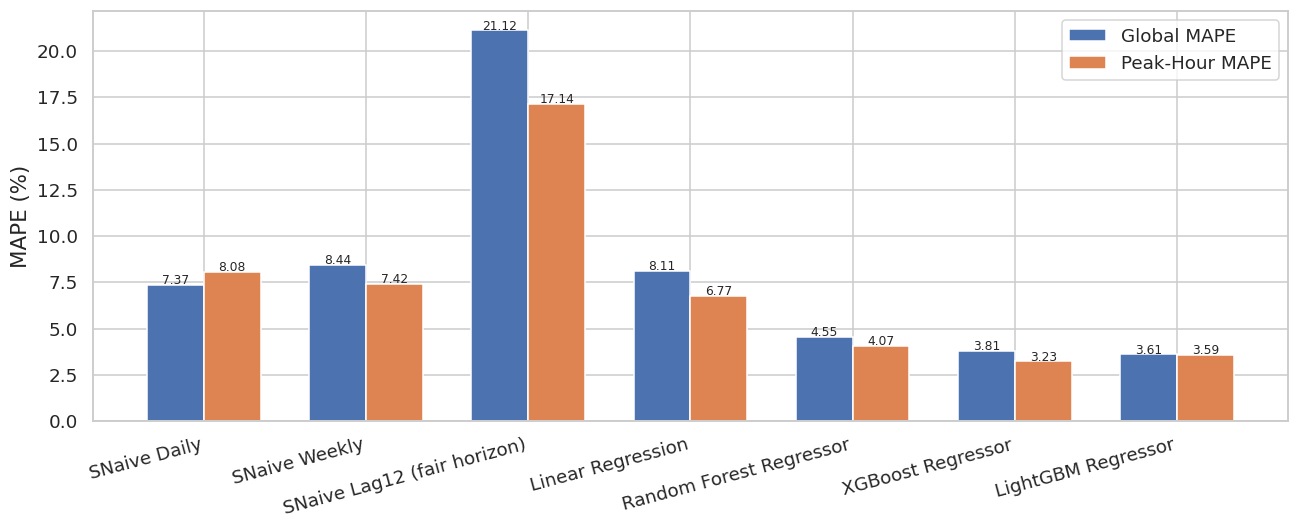

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(bang_rq5))
width = 0.35
ax.bar(x - width/2, bang_rq5["MAPE Toàn cục (%)"], width, label="Global MAPE", color="#4C72B0")
ax.bar(x + width/2, bang_rq5["MAPE Cao điểm (%)"], width, label="Peak-Hour MAPE", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(bang_rq5["Model Name"], rotation=15, ha="right")
ax.set_ylabel("MAPE (%)")
ax.legend()
for i, (g, p) in enumerate(zip(bang_rq5["MAPE Toàn cục (%)"], bang_rq5["MAPE Cao điểm (%)"])):
    ax.text(i - width/2, g + 0.05, f"{g:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, p + 0.05, f"{p:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("peak_period_impact.png", dpi=300, bbox_inches="tight")   # MỚI
plt.show()


**Trả lời:**

Khung giờ cao điểm (chu kỳ 15 đến 18 và 35 đến 38, tương ứng 07:00–09:00 và 17:00–19:00) chiếm 2.920/17.520 chu kỳ trong Test 2025, khoảng 16,7%.

Kết quả trái ngược hoàn toàn với giả thuyết: **mọi mô hình học máy đều dự báo CHÍNH XÁC HƠN tại giờ cao điểm chứ không hề suy giảm.** Linear Regression giảm MAPE từ 8,11% xuống 6,77% (cải thiện 1,34 điểm phần trăm), Random Forest từ 4,55% xuống 4,07% (cải thiện 0,47 điểm), XGBoost từ 3,81% xuống 3,23% (cải thiện 0,58 điểm), LightGBM gần như không đổi (3,61% xuống 3,59%). Hai baseline SNaive biến động không nhất quán: SNaive Daily tệ đi ở cao điểm (7,37% lên 8,08%), còn SNaive Weekly lại tốt lên (8,44% xuống 7,42%).

Nguyên nhân chủ yếu mang tính cấu trúc của chỉ số MAPE: giờ cao điểm là lúc nhu cầu điện đạt mức cao nhất trong ngày, nên cùng một sai số tuyệt đối tính bằng MW sẽ quy đổi thành tỷ lệ phần trăm nhỏ hơn. Điều này không có nghĩa mô hình dự báo dễ dàng hơn ở giờ cao điểm về mặt tuyệt đối, nhưng ở góc độ vận hành — nơi sai số tương đối mới là thứ ảnh hưởng đến quyết định huy động công suất — đây là một đặc tính rất thuận lợi.

**Kết luận H5:** BỊ BÁC BỎ. MAPE tại giờ cao điểm không những không cao hơn mà còn thấp hơn MAPE toàn cục ở toàn bộ bốn mô hình học máy. Về mặt thực tiễn, đây là kết quả tích cực: các mô hình giữ được, thậm chí cải thiện, độ chính xác tương đối tại chính những chu kỳ quyết toán có ý nghĩa nhất đối với cân bằng lưới điện.

### 6.7 Tổng kết kiểm định giả thuyết




**Nhận xét kết luận**

Tổng hợp sáu câu hỏi nghiên cứu trên tập đặc trưng đã được sửa (độ trễ tối thiểu 12 chu kỳ, tương ứng tầm dự báo 6 giờ):

- **RQ1a (ỦNG HỘ):** SNaive Daily là baseline ngây thơ mạnh hơn nói chung, đặc biệt vào ngày thường (chênh lệch MAE 457,61 MW); hai baseline ngang nhau vào cuối tuần.
- **RQ1b (ỦNG HỘ MỘT PHẦN):** ba mô hình cây vượt trội cả hai baseline (LightGBM Tuned giảm RMSE 51,9% so với SNaive Daily), nhưng Linear Regression lại THUA SNaive Daily ở MAE và MAPE — bằng chứng trực tiếp cho thấy bài toán mang bản chất phi tuyến.
- **RQ2 (KHÔNG ỦNG HỘ):** mã hoá giờ trong ngày (trung bình 4,65% MAE) không vượt trội so với mã hoá thứ trong tuần (4,95%); các độ trễ 48 và 336 chu kỳ đã mã hoá gián tiếp thông tin giờ trong ngày. Cờ `IS_WEEKEND` dư thừa.
- **RQ3 (ỦNG HỘ):** mùa vụ đơn điệu (Winter > Autumn > Spring > Summer, không có đỉnh hè); mô hình cây nắm bắt tương tác mùa vụ tốt hơn hẳn mô hình tuyến tính, nhưng XGBoost và LightGBM thay nhau dẫn đầu tuỳ mùa.
- **RQ4 (ỦNG HỘ MẠNH):** năng lượng tái tạo nhúng đóng góp lớn hơn nhiều so với ước lượng ban đầu (LightGBM tăng 39,01% MAE nếu loại bỏ), và tầm quan trọng tăng lên rõ rệt ở tầm dự báo xa.
- **RQ5 (BỊ BÁC BỎ):** mọi mô hình học máy đều có MAPE tại giờ cao điểm THẤP HƠN MAPE toàn cục, không hề suy giảm như giả thuyết.

Xuyên suốt sáu câu hỏi, **LightGBM Regressor (Tuned)** là mô hình mạnh nhất tổng thể (MAE 904,68 MW, RMSE 1.240,78 MW, MAPE 3,59%, R² 0,9596), với XGBoost bám rất sát. Khác với phiên bản trước, bước tinh chỉnh siêu tham số lần này CÓ cải thiện hiệu năng cho cả hai mô hình boosting, dù mức cải thiện nhỏ (dưới 1%).

Điểm quan trọng nhất về mặt phương pháp luận: toàn bộ kết quả trên được đo ở tầm dự báo 6 giờ, sau khi loại bỏ các độ trễ 1 và 2 chu kỳ vốn khiến mô hình gần như đọc lại chính giá trị cần dự báo. Các chỉ số vì thế thấp hơn đáng kể so với phiên bản trước ($R^2$ 0,96 thay vì 0,997), nhưng phản ánh trung thực năng lực dự báo thực sự và cho phép so sánh công bằng với hai đường cơ sở SNaive.